# Community ECS assessment

Clean driver for [`community_ecs.stan`](community_ecs.stan). The notebook keeps assessed numerical inputs separate from model switches, runs named scenarios, and stores both live results and durable run files.

Use the **`stan` mamba environment** for this notebook. Run the cells from top to bottom.

In [3]:
import json
import re
import sys
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, norm, skewnorm

# Work whether Jupyter starts in bayecs/ or in its parent directory.
root = Path.cwd().resolve()
if not (root / "community_ecs.stan").exists():
    candidate = root / "bayecs"
    if (candidate / "community_ecs.stan").exists():
        root = candidate

stan_file = root / "community_ecs.stan"
assert stan_file.exists(), f"Stan file not found: {stan_file}"

# The stan environment bundles CmdStan at <environment>/bin/cmdstan.
# Use CmdStanPy's configured location when available, with that local
# environment path as a fallback.
env_bin = Path(sys.executable).resolve().parent
try:
    cmdstan_path = Path(cmdstanpy.cmdstan_path())
except ValueError:
    env_cmdstan = env_bin / "cmdstan"
    if not env_cmdstan.exists():
        raise RuntimeError(
            "CmdStan was not found. Run this notebook with the stan mamba environment."
        )
    cmdstanpy.set_cmdstan_path(str(env_cmdstan))
    cmdstan_path = env_cmdstan

# Prefer the stan environment's matching GNU compiler over any compiler
# inherited from the host's shell modules. This avoids TBB ABI conflicts.
env_cxx = env_bin / "x86_64-conda-linux-gnu-g++"
cpp_options = {"CXX": str(env_cxx)} if env_cxx.exists() else {}

print("Stan file:", stan_file)
print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", cmdstan_path)
print("C++ compiler:", cpp_options.get("CXX", "CmdStan default"))

Stan file: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs.stan
CmdStanPy: 1.2.1
CmdStan: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/cmdstan
C++ compiler: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/x86_64-conda-linux-gnu-g++


In [4]:
import matplotlib as mpl
import seaborn as sns

## Match the serif plotting style used in grl_eei_update.ipynb.
sns.set_context("paper")
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "TeX Gyre Termes",
        "Times New Roman",
        "Times",
        "STIXGeneral",
    ],
    "mathtext.fontset": "stix",
    "mathtext.rm": "serif",
    "mathtext.it": "serif:italic",
    "mathtext.bf": "serif:bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


## Assessed inputs

These are the current central values and 1-sigma uncertainties. Every input remains present even when its line of evidence is disabled, because the unified Stan model has one fixed data interface.

In [5]:
## Process components

## --------------- cloud ---------------
## Component means and standard deviations are the latest values from
## cloud_assess.ipynb. The Stan model receives only the aggregate
## cloud_total_mu and cloud_total_sig calculated below.
marine_lowcloud_mu = 0.30975
marine_lowcloud_sig = 0.211013

highcloud_amt_optdepth_mu = 0.01350
highcloud_amt_optdepth_sig = 0.114829

highcloud_alt_mu = 0.24180
highcloud_alt_sig = 0.125454

landcloud_mu = 0.08
landcloud_sig = 0.08

unassessed_cloud_mu = 0.0
unassessed_cloud_sig = 0.10

## Means and variances add under the assumed component independence.
cloud_total_mu = (
    marine_lowcloud_mu + 
    highcloud_amt_optdepth_mu +
    highcloud_alt_mu + 
    landcloud_mu +
    unassessed_cloud_mu
)
cloud_total_sig = (
    marine_lowcloud_sig**2 + 
    highcloud_amt_optdepth_sig**2 +
    highcloud_alt_sig**2 + 
    landcloud_sig**2 +
    unassessed_cloud_sig**2
)**0.5
print('Total cloud input: ', np.round(cloud_total_mu,3), '±', np.round(cloud_total_sig,3), 'W m-2 K-1')

## --------------- noncloud ---------------
# Kuma weighting on CMIP6, in line with SW20 and AR6
planck_mu  = -3.23
planck_sig = 0.11 ## 0.10 kernel spread, Janowski and Zelinka/Forster, 0.04 intermodel spread

# from SW20 and Colman & Soden 2021
LRWV_mu = 1.27 ## 1.25 joint ancestry + 0.02 strat
LRWV_sig = 0.18 ## see paper

# from AR6
surfalbedo_mu  = 0.39 
surfalbedo_sig = 0.15

noncloud_total_mu = (
    planck_mu + LRWV_mu + surfalbedo_mu
)
noncloud_total_sig = (
    planck_sig**2 + LRWV_sig**2 + surfalbedo_sig**2
)**0.5

print('Total noncloud: ', np.round(noncloud_total_mu,3), '±', np.round(noncloud_total_sig,3), 'W m-2 K-1')

## --------------- unassessed non-cloud ---------------
unassessed_mu = 0.0
unassessed_sig = 0.16

## --------------- total process ---------------
process_lamb_mu = (
    cloud_total_mu + noncloud_total_mu + unassessed_mu
)
process_lamb_sig = (
    cloud_total_sig**2 + noncloud_total_sig**2 + unassessed_sig**2
)**0.5
print('Total process: ', np.round(process_lamb_mu,4), '±', np.round(process_lamb_sig,4), 'W m-2 K-1')

Total cloud input:  0.645 ± 0.3 W m-2 K-1
Total noncloud:  -1.57 ± 0.259 W m-2 K-1
Total process:  -0.9249 ± 0.4271 W m-2 K-1


In [9]:
## Common inputs, used lated in the dictionary
erf_2x = 3.93
sig_erf_2x = 0.29
co2_pi = 284.7

## Reflected-lognormal prior on the positive damping r = -lambda.
## These match the final prior comparison in grl_eei_update.ipynb.
# lognormal_r_median = 1.
# lognormal_r_log_sigma = 0.8
lognormal_r_median = np.exp(3.0)       
lognormal_r_log_sigma = np.sqrt(3.)

## Instrumental pattern-effect skew-normal parameters.
## Note default inputs give -0.62 median pattern effect.
## Setting shape=0 yields a normal(mean=loc,sd=scale).
instrumental_dlambda_shape = -3.7573
instrumental_dlambda_loc = 0.9726
instrumental_dlambda_scale = 0.5195

## paleo pattern effect correlation
rho_LGM_plio = 0.5 #0.54

# ----- OPTIONAL -----
# Latent-Gaussian correlations used only when the copula is enabled.
# The instrumental values induce approximately -0.10 Pearson correlation
# with the present skew-normal instrumental marginal.
rho_instrumental_LGM = 0. #-0.10
rho_instrumental_plio = 0. #-0.10

# Optional Process-lambda / ERF2x correlation. Negative means that a
# larger (more-positive) F_2xCO2 accompanies a more-negative lambda.
rho_lambda_F2x = 0. #-0.50

# 2006--2024 ERF-trend decomposition. Anthropogenic aerosol is ARI+ACI.
# The aerosol trend has paired-ensemble and additional structural spreads.
# Both covariance choices retain the structural contribution to variance.
# CO2 uncertainty is inherited from F2x and is not added independently.
mu_F_CO2_trend = 0.329
mu_F_anthro_aerosol_trend = 0.200
sig_F_anthro_aerosol_instrumental = 0.342
sig_F_anthro_aerosol_trend_ensemble = 0.143
sig_F_anthro_aerosol_trend_structural = 0.10
rho_F_anthro_aerosol_struct_instrumental = -0.5043638097
sig_F_anthro_aerosol_trend = np.sqrt(
    sig_F_anthro_aerosol_trend_ensemble**2
    + sig_F_anthro_aerosol_trend_structural**2
)
mu_F_other_trend = 0.150
sig_F_other_trend = 0.016

# Paired IGCC covariance between the instrumental forcing change and the
# 2006--2024 trend. Choose whether the additional structural aerosol error
# contributes to covariance. Change this one setting to compare assumptions.
cov_F_anthro_aerosol_instrumental_trend_ensemble = -0.0247083552
aerosol_structural_covariance_mode = "correlated"  # or "independent"
cov_F_anthro_aerosol_instrumental_trend_options = {
    "independent": cov_F_anthro_aerosol_instrumental_trend_ensemble,
    "correlated": (
        cov_F_anthro_aerosol_instrumental_trend_ensemble
        + rho_F_anthro_aerosol_struct_instrumental
        * sig_F_anthro_aerosol_instrumental
        * sig_F_anthro_aerosol_trend_structural
    ),
}
cov_F_anthro_aerosol_instrumental_trend = (
    cov_F_anthro_aerosol_instrumental_trend_options[
        aerosol_structural_covariance_mode
    ]
)
cov_F_other_instrumental_trend = 0.00108444987

base_inputs = {
    # Shared forcing
    "erf_2x": erf_2x,
    "sig_F2xCO2": sig_erf_2x,
    "rho_lambda_F2x": rho_lambda_F2x,

    # Reflected-lognormal lambda-prior parameters
    "lognormal_r_median": lognormal_r_median,
    "lognormal_r_log_sigma": lognormal_r_log_sigma,

    # Process evidence
    "mu_lambda": process_lamb_mu,
    "sig_lambda": process_lamb_sig,

    # Instrumental evidence
    "mu_T_instrumental": 1.09,
    "sig_T_instrumental": np.sqrt(0.08**2 + 0.07**2), ## observational + internal variability
    "mu_N_instrumental": 0.81,
    "sig_N_instrumental": 0.20,
    "mu_F_CO2_instrumental": 1.80,
    "mu_F_anthro_aerosol_instrumental": -0.970,
    "sig_F_anthro_aerosol_instrumental": sig_F_anthro_aerosol_instrumental,
    "mu_F_other_instrumental": 1.820,
    "sig_F_other_instrumental": 0.175,
    "shape_dlambda_instrumental": instrumental_dlambda_shape,
    "loc_dlambda_instrumental": instrumental_dlambda_loc,
    "scale_dlambda_instrumental": instrumental_dlambda_scale,

    # 2006--2024 Trend evidence (per decade)
    "mu_F_CO2_trend": mu_F_CO2_trend,
    "mu_F_anthro_aerosol_trend": mu_F_anthro_aerosol_trend,
    "sig_F_anthro_aerosol_trend": sig_F_anthro_aerosol_trend,
    "mu_F_other_trend": mu_F_other_trend,
    "sig_F_other_trend": sig_F_other_trend,
    "cov_F_anthro_aerosol_instrumental_trend": (
        cov_F_anthro_aerosol_instrumental_trend
    ),
    "cov_F_other_instrumental_trend": cov_F_other_instrumental_trend,
    "mu_T_trend": 0.297,
    "sig_T_trend": 0.071,
    "mu_N_trend": 0.452,
    "sig_N_trend": 0.161,
    "cov_TN_trend": -0.00297,
    "mu_dlambda_trend": 0.0,
    "sig_dlambda_trend": 0.30,

    # LGM evidence
    "mu_T_LGM": -6.0,
    "sig_T_LGM": 0.9,
    "mu_F_other_LGM": -4.45,
    "sig_F_other_LGM": 1.86,
    "mu_f_CO2_LGM": -0.55,
    "sig_f_CO2_LGM": 0.04,
    "mu_N_LGM": -0.03,
    "sig_N_LGM": 0.03,
    # "sig_N_LGM": 0.1 / 1.645,
    "mu_dlambda_LGM": -0.35,
    "sig_dlambda_LGM": 0.35,

    # mPWP evidence
    "mu_T_plio": 3.9, #4.1, #3.9±0.9 for KM5c
    "sig_T_plio": 0.9, #0.6,
    "mu_CO2_plio": 391, #367.0, #391±29 for KM5c
    "sig_CO2_plio": 21, #(2*15^2)^0.5 double variance, #15 (1sigma) #30 2sigma
    "CO2_PI": co2_pi,
    "mu_F_plio_nonGHG": 1.6, # PlioMIP2 BCs designed for KM5c
    "sig_F_plio_nonGHG": 0.8,
    "mu_N_plio": 0.0,
    "sig_N_plio": 0.01,# / 1.645,
    "mu_dlambda_plio": -0.38,
    "sig_dlambda_plio": 0.40,
    "mu_fCH4": 0.43,
    "sig_fCH4": 0.08,

    # Pattern-effect correlations
    "rho_dlambda_instrumental_LGM": rho_instrumental_LGM,
    "rho_dlambda_instrumental_plio": rho_instrumental_plio,
    "rho_dlambda_LGM_plio": rho_LGM_plio,
}

print(f"{len(base_inputs)} assessed inputs defined")

59 assessed inputs defined


## Model switches

Most settings are binary. `lambda_prior_type` is categorical: `0` selects uniform $S$, `1` selects uniform $\lambda$, and `2` selects a reflected lognormal on the positive damping $r=-\lambda$. The notebook constants `lambda_prior_types` avoid needing to remember those integers. The prior choice remains available whether Process evidence is on or off. `use_lambda_F2x_correlation=1` uses the assessed `rho_lambda_F2x` in a bivariate Gaussian Process/forcing term and therefore requires Process evidence.

The baseline requested here uses a uniform-lambda prior, includes Process, Instrumental, Trend, LGM, and Pliocene, and uses $N$-based energy budget equations. Set `use_score_T=1` to rearrange every enabled energy-budget equation in terms of $T$ instead of $N$. When Instrumental and Trend are both enabled, the matching aerosol and residual-other forcing components use the assessed cross-period covariances in `base_inputs`; no instrumental–Trend covariance is yet applied to $T$, $N$, or pattern effects. `aerosol_structural_covariance_mode` selects whether the additional aerosol-trend structural error is independent of instrumental forcing or contributes covariance using the assessed aerosol anti-correlation.

In [10]:
lambda_prior_types = {
    "uniform_S": 0,
    "uniform_lambda": 1,
    "lognormal_lambda": 2,
}

switch_names = (
    "lambda_prior_type",
    "include_process",
    "use_lambda_F2x_correlation",
    "include_instrumental",
    "include_trend",
    "include_lgm",
    "include_pliocene",
    "use_score_T",
    "use_pattern_effect_copula",
)

binary_switch_names = tuple(
    name for name in switch_names if name != "lambda_prior_type"
)

baseline_switches = {
    "lambda_prior_type": lambda_prior_types["uniform_lambda"],
    "include_process": 1,
    "use_lambda_F2x_correlation": 0,
    "include_instrumental": 1,
    "include_trend": 1,
    "include_lgm": 1,
    "include_pliocene": 1,
    "use_score_T": 0,
    "use_pattern_effect_copula": 0,
}

def _validate_data(data):
    expected = set(base_inputs) | set(switch_names)
    missing = expected - set(data)
    extra = set(data) - expected
    if missing or extra:
        raise ValueError(f"Data keys differ from expected; missing={missing}, extra={extra}")

    bad_switches = {
        k: data[k] for k in binary_switch_names if data[k] not in (0, 1)
    }
    if bad_switches:
        raise ValueError(f"Binary switches must be 0 or 1: {bad_switches}")

    if data["lambda_prior_type"] not in lambda_prior_types.values():
        raise ValueError(
            f"lambda_prior_type must be one of {lambda_prior_types}: "
            f"got {data['lambda_prior_type']}"
        )
    if data["lognormal_r_median"] <= 0:
        raise ValueError("lognormal_r_median must be positive")
    if data["lognormal_r_log_sigma"] <= 0:
        raise ValueError("lognormal_r_log_sigma must be positive")

    if data["use_lambda_F2x_correlation"]:
        if not data["include_process"]:
            raise ValueError(
                "lambda/F_2xCO2 correlation requires include_process=1"
            )
        if not -1 < data["rho_lambda_F2x"] < 1:
            raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    if data["include_trend"]:
        trend_cov = np.array([
            [data["sig_T_trend"]**2, data["cov_TN_trend"]],
            [data["cov_TN_trend"], data["sig_N_trend"]**2],
        ])
        np.linalg.cholesky(trend_cov)

    if data["include_instrumental"] and data["include_trend"]:
        aerosol_forcing_cov = np.array([
            [
                data["sig_F_anthro_aerosol_instrumental"]**2,
                data["cov_F_anthro_aerosol_instrumental_trend"],
            ],
            [
                data["cov_F_anthro_aerosol_instrumental_trend"],
                data["sig_F_anthro_aerosol_trend"]**2,
            ],
        ])
        other_forcing_cov = np.array([
            [
                data["sig_F_other_instrumental"]**2,
                data["cov_F_other_instrumental_trend"],
            ],
            [
                data["cov_F_other_instrumental_trend"],
                data["sig_F_other_trend"]**2,
            ],
        ])
        np.linalg.cholesky(aerosol_forcing_cov)
        np.linalg.cholesky(other_forcing_cov)

    if data["use_pattern_effect_copula"]:
        copula_r = np.array([
            [1.0, data["rho_dlambda_instrumental_LGM"], data["rho_dlambda_instrumental_plio"]],
            [data["rho_dlambda_instrumental_LGM"], 1.0, data["rho_dlambda_LGM_plio"]],
            [data["rho_dlambda_instrumental_plio"], data["rho_dlambda_LGM_plio"], 1.0],
        ])
        np.linalg.cholesky(copula_r)
    elif not -1 < data["rho_dlambda_LGM_plio"] < 1:
        raise ValueError("rho_dlambda_LGM_plio must lie strictly between -1 and 1")


def make_data(switch_updates=None, input_updates=None):
    """Build and validate one complete community_ecs.stan data dictionary."""
    switches = dict(baseline_switches)
    switch_updates = {} if switch_updates is None else dict(switch_updates)
    input_updates = {} if input_updates is None else dict(input_updates)

    unknown_switches = set(switch_updates) - set(switch_names)
    unknown_inputs = set(input_updates) - set(base_inputs)
    if unknown_switches:
        raise KeyError(f"Unknown model switches: {sorted(unknown_switches)}")
    if unknown_inputs:
        raise KeyError(f"Unknown assessed inputs: {sorted(unknown_inputs)}")

    switches.update(switch_updates)
    inputs = dict(base_inputs)
    inputs.update(input_updates)
    data = dict(inputs, **switches)
    _validate_data(data)
    return data


baseline_data = make_data()
pd.Series(baseline_switches, name="baseline").to_frame()

,baseline
lambda_prior_type,1
include_process,1
use_lambda_F2x_correlation,0
include_instrumental,1
include_trend,1
include_lgm,1
include_pliocene,1
use_score_T,0
use_pattern_effect_copula,0


## Initialization and sampling controls

The model samples `lamb` (lambda) directly and reports `S` as a transformed parameter. Initial values therefore contain `lamb`, not `S`. Both score conventions need initial values for their fixed-interface nuisance parameters; the inactive set has a proper, disconnected distribution and cannot affect the shared posterior. The default sampling size is suitable for comparisons; increase `iter_sampling` for final tail estimates if needed.

In [11]:
def make_init(data, ecs_initial=4.0, init_updates=None):
    init = {
        "F_2xCO2": data["erf_2x"],
        "lamb": -data["erf_2x"] / ecs_initial,
        "F_anthro_aerosol_instrumental": data["mu_F_anthro_aerosol_instrumental"],
        "F_other_instrumental": data["mu_F_other_instrumental"],
        "T_instrumental": data["mu_T_instrumental"],
        "N_instrumental_scoreT": data["mu_N_instrumental"],
        "dlambda_instrumental": skewnorm.ppf(
            0.5, a=data["shape_dlambda_instrumental"],
            loc=data["loc_dlambda_instrumental"], scale=data["scale_dlambda_instrumental"],
        ),
        "T_LGM": data["mu_T_LGM"],
        "N_LGM_scoreT": data["mu_N_LGM"],
        "F_other_LGM": data["mu_F_other_LGM"],
        "f_CO2_LGM": data["mu_f_CO2_LGM"],
        "dlambda_LGM": data["mu_dlambda_LGM"],
        "T_plio": data["mu_T_plio"],
        "N_plio_scoreT": data["mu_N_plio"],
        "CO2_plio": data["mu_CO2_plio"],
        "F_plio_nonGHG": data["mu_F_plio_nonGHG"],
        "dlambda_plio": data["mu_dlambda_plio"],
        "fCH4": data["mu_fCH4"],
        "F_anthro_aerosol_trend": data["mu_F_anthro_aerosol_trend"],
        "F_other_trend": data["mu_F_other_trend"],
        "T_trend": data["mu_T_trend"],
        "N_trend_scoreT": data["mu_N_trend"],
        "dlambda_trend": data["mu_dlambda_trend"],
    }
    if init_updates:
        unknown = set(init_updates) - set(init)
        if unknown:
            raise KeyError(f"Unknown initial-value parameters: {sorted(unknown)}")
        init.update(init_updates)
    return init


sampling_defaults = {
    "chains": 4,
    "parallel_chains": 4,
    # Quick comparison defaults; increase these for final tail estimates.
    "iter_warmup": 1_000,
    "iter_sampling": 5_000,
    "adapt_delta": 0.95,
    "max_treedepth": 12,
    "seed": 20250812,
    "show_progress": True,
    "show_console": False,
    "refresh": 500,
}

make_init(baseline_data)

{'F_2xCO2': 3.93,
 'lamb': -0.9825,
 'F_anthro_aerosol_instrumental': -0.97,
 'F_other_instrumental': 1.82,
 'T_instrumental': 1.09,
 'N_instrumental_scoreT': 0.81,
 'dlambda_instrumental': 0.6224390559414669,
 'T_LGM': -6.0,
 'N_LGM_scoreT': -0.03,
 'F_other_LGM': -4.45,
 'f_CO2_LGM': -0.55,
 'dlambda_LGM': -0.35,
 'T_plio': 3.9,
 'N_plio_scoreT': 0.0,
 'CO2_plio': 391,
 'F_plio_nonGHG': 1.6,
 'dlambda_plio': -0.38,
 'fCH4': 0.43,
 'F_anthro_aerosol_trend': 0.2,
 'F_other_trend': 0.15,
 'T_trend': 0.297,
 'N_trend_scoreT': 0.452,
 'dlambda_trend': 0.0}

In [12]:
community_model = cmdstanpy.CmdStanModel(
    stan_file=str(stan_file), cpp_options=cpp_options
)
print("Compiled model:", community_model.exe_file)

10:28:33 - cmdstanpy - INFO - compiling stan file /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs.stan to exe file /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs
10:30:06 - cmdstanpy - INFO - compiled model executable: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs


Compiled model: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs


## Reusable scenario runner

Each completed run is placed in `results[name]`. CmdStan CSV files, the exact input data, run metadata, and a summary CSV are also written beneath `community_ecs_results/`. A rerun with the same name replaces the in-memory entry but does not overwrite the earlier timestamped directory.

In [13]:
results_root = root / "community_ecs_results"
results = {}


def run_scenario(
    name, *, switch_updates=None, input_updates=None,
    sampling_updates=None, init_updates=None, ecs_initial=4.0,
):
    """Run one named scenario and save its fit, inputs, and summaries."""
    if not re.fullmatch(r"[A-Za-z0-9_.-]+", name):
        raise ValueError("name may contain only letters, numbers, '.', '_' and '-'")

    data = make_data(switch_updates=switch_updates, input_updates=input_updates)
    inits = make_init(data, ecs_initial=ecs_initial, init_updates=init_updates)
    sampling = dict(sampling_defaults)
    if sampling_updates:
        sampling.update(sampling_updates)

    stamp = datetime.now().strftime("%Y%m%dT%H%M%S_%f")
    run_dir = results_root / f"{name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=False)
    cmdstanpy.write_stan_json(str(run_dir / "data.json"), data)

    metadata = {
        "name": name,
        "created": stamp,
        "stan_file": str(stan_file),
        "switches": {key: data[key] for key in switch_names},
        "sampling": sampling,
    }
    with (run_dir / "metadata.json").open("w") as handle:
        json.dump(metadata, handle, indent=2)

    print(f"Running {name!r}")
    print("Switches:", metadata["switches"])
    fit = community_model.sample(
        data=data, inits=inits, output_dir=str(run_dir), **sampling
    )
    summary = fit.summary()
    summary.to_csv(run_dir / "summary.csv")

    entry = {
        "fit": fit,
        "data": data,
        "inits": inits,
        "switches": metadata["switches"],
        "sampling": sampling,
        "summary": summary,
        "S": fit.stan_variable("S"),
        "lamb": fit.stan_variable("lamb"),
        "output_dir": run_dir,
    }
    results[name] = entry

    divergences = int(np.sum(fit.method_variables()["divergent__"]))
    s_quantiles = np.quantile(entry["S"], [0.05, 0.17, 0.50, 0.83, 0.95])
    print("S quantiles [5, 17, 50, 83, 95]%:", np.round(s_quantiles, 3))
    print("Divergences:", divergences)
    print("Saved to:", run_dir)
    return entry


def compare_scenarios(names=None):
    """Return an ECS comparison table for completed scenarios."""
    names = list(results) if names is None else list(names)
    rows = []
    for name in names:
        entry = results[name]
        s = entry["S"]
        q = np.quantile(s, [0.05, 0.17, 0.50, 0.83, 0.95])
        fit = entry["fit"]
        rows.append({
            "scenario": name,
            "mean": np.mean(s),
            "sd": np.std(s, ddof=1),
            "p05": q[0], "p17": q[1], "p50": q[2],
            "p83": q[3], "p95": q[4],
            "divergences": int(np.sum(fit.method_variables()["divergent__"])),
            "R_hat_S": entry["summary"].loc["S", "R_hat"],
            "ESS_bulk_S": entry["summary"].loc["S", "ESS_bulk"],
        })
    return pd.DataFrame(rows).set_index("scenario").round(3)

## Baseline calculation

This runs the requested baseline: uniform lambda, Process + Instrumental + Trend + LGM + Pliocene, score $N$, no three-way pattern-effect copula, and no optional lambda/ERF2x correlation.

In [14]:
baseline = run_scenario("baseline")#, sampling_updates={'iter_sampling': 40_000})
compare_scenarios()

10:30:06 - cmdstanpy - INFO - CmdStan start processing


Running 'baseline'
Switches: {'lambda_prior_type': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_instrumental': 1, 'include_trend': 1, 'include_lgm': 1, 'include_pliocene': 1, 'use_score_T': 0, 'use_pattern_effect_copula': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:31:49 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [2.553 2.887 3.491 4.351 5.276]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/baseline_20260911T103006_180140


,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.65,0.885,2.553,2.887,3.491,4.351,5.276,0,1.0,13630.0


In [15]:
summary_variables = [
    "S", "lamb", "F_2xCO2",
    "dlambda_instrumental", "dlambda_LGM", "dlambda_plio",
    "F_CO2_instrumental", "F_anthro_aerosol_instrumental", "F_other_instrumental", "F_instrumental",
    "f_CO2_LGM", "F_CO2_LGM",
    "CO2_plio", "f_CO2_plio", "F_plio_CO2",
    "N_instrumental", "T_instrumental_scoreT",
    "F_CO2_trend", "F_anthro_aerosol_trend",
    "F_other_trend", "F_trend",
    "N_trend", "T_trend_scoreT",
    "N_LGM", "T_LGM_scoreT",
    "N_plio", "T_plio_scoreT",
]
baseline["summary"].loc[summary_variables].round(3)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.650,0.008,0.885,0.727,2.553,3.491,5.276,13630.0,11500.7,41.166,1.000
lamb,-1.129,0.002,0.242,0.241,-1.532,-1.126,-0.737,14965.2,11677.0,45.199,1.000
F_2xCO2,3.928,0.002,0.284,0.278,3.460,3.928,4.394,33463.3,13224.8,101.068,1.000
dlambda_instrumental,0.566,0.002,0.281,0.284,0.062,0.597,0.976,18116.3,13009.2,54.716,1.000
dlambda_LGM,-0.146,0.002,0.275,0.278,-0.600,-0.145,0.309,16778.9,14061.7,50.677,1.000
dlambda_plio,-0.141,0.002,0.291,0.290,-0.611,-0.145,0.345,15590.3,14996.6,47.087,1.000
F_CO2_instrumental,1.799,0.001,0.130,0.128,1.585,1.799,2.013,33463.3,13224.8,101.068,1.000
F_anthro_aerosol_instrumental,-1.011,0.002,0.257,0.258,-1.438,-1.009,-0.595,19063.8,15320.7,57.578,1.000
F_other_instrumental,1.832,0.001,0.170,0.170,1.552,1.832,2.112,26184.5,16084.5,79.084,1.000
F_instrumental,2.620,0.002,0.301,0.304,2.120,2.622,3.113,21334.4,15996.9,64.436,1.000


## Alternative settings

Uncomment any example below. Only settings that differ from the baseline need to be supplied. You can also change assessed values for a sensitivity test through `input_updates`.

In [16]:
## Sensitivity: exclude recent Trend evidence while retaining Instrumental.
# without_trend = run_scenario(
#     "without_trend", switch_updates={"include_trend": 0}
# )

# plio_CO2_coldex = run_scenario(
#     "plio_CO2_coldex",
#     input_updates={
#         "mu_CO2_plio": 250.,
#         "sig_CO2_plio": 21., #use 2sigma as 1sigma because age uncertainty
#     },
# )

## Sensitivity: retain the extra aerosol-trend spread but use the
## independent structural-error covariance option.
# independent_structural = run_scenario(
#     "independent_structural",
#     input_updates={
#         "cov_F_anthro_aerosol_instrumental_trend":
#             cov_F_anthro_aerosol_instrumental_trend_options["independent"]
#     },
# )

## Retain Trend but exclude Instrumental
# trend_no_instrumental = run_scenario(
#     "trend_no_instrumental", switch_updates={"include_instrumental": 0}
# )

# Exclude paleo
no_paleo = run_scenario(
    "no_paleo", switch_updates={"include_lgm": 0,
                                "include_pliocene": 0}
)

no_paleo_US = run_scenario(
    "no_paleo_US", 
    switch_updates={"include_lgm": 0,
                    "include_pliocene": 0,
                    "lambda_prior_type": lambda_prior_types["uniform_S"],
                   }
)




## Use SW20 form of energy budget equations (forward model for T)
# score_T = run_scenario(
#     "score_T", switch_updates={"use_score_T": 1}
# )

## [test of allowing correlation between F2x and lambda_2x]
# with_lambda_F2x_correlation = run_scenario(
#     "with_lambda_F2x_correlation",
#     switch_updates={"use_lambda_F2x_correlation": 1},
#     # Uses the default rho_lambda_F2x=-0.5. override if desired, with:
#     # input_updates={"rho_lambda_F2x": -0.3},
# )


## [probably can remove this] Test of small anti-correlation 
## between instrumental and paleo pattern effects.
# with_copula = run_scenario(
#     "with_copula", switch_updates={"use_pattern_effect_copula": 1}
# )

## exclude process
# no_process_uniform_lambda = run_scenario(
#     "no_process_UL", switch_updates={"include_process": 0}
# )

## Uniform S prior
# uniform_S = run_scenario(
#     "unif_S",
#     switch_updates={
#         "lambda_prior_type": lambda_prior_types["uniform_S"]
#     },
# )

# ## lognormal lambda prior
lognormal_lambda = run_scenario(
    "lognormal_lambda",
    switch_updates={
        "lambda_prior_type": lambda_prior_types["lognormal_lambda"],
        # "include_instrumental": 1,
    },
)

10:31:51 - cmdstanpy - INFO - CmdStan start processing


Running 'no_paleo'
Switches: {'lambda_prior_type': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_instrumental': 1, 'include_trend': 1, 'include_lgm': 0, 'include_pliocene': 0, 'use_score_T': 0, 'use_pattern_effect_copula': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:33:45 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [2.568 2.89  3.482 4.33  5.227]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/lognormal_lambda_20260911T103201_714329


In [21]:
process_only_US = run_scenario(
    "process_only_US",
    switch_updates={
        "lambda_prior_type": lambda_prior_types["uniform_S"],
        "include_lgm": 0,
        "include_pliocene": 0,
        "include_trend": 0,
        "include_instrumental": 0,
    },
)

10:36:59 - cmdstanpy - INFO - CmdStan start processing


Running 'process_only_US'
Switches: {'lambda_prior_type': 0, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_instrumental': 0, 'include_trend': 0, 'include_lgm': 0, 'include_pliocene': 0, 'use_score_T': 0, 'use_pattern_effect_copula': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:37:02 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [ 3.117  4.259  7.74  14.342 18.158]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/process_only_US_20260911T103659_409629


In [22]:
# Compare every completed scenario.
compare_scenarios()

,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.650,0.885,2.553,2.887,3.491,4.351,5.276,0,1.0,13630.0
no_paleo,4.563,1.874,2.713,3.186,4.109,5.719,7.884,0,1.0,12458.2
no_paleo_US,6.423,3.412,3.119,3.776,5.334,8.891,14.278,0,1.0,12657.1
lognormal_lambda,3.637,0.869,2.568,2.890,3.482,4.330,5.227,0,1.0,14538.0
process_only_US,8.927,4.731,3.117,4.259,7.740,14.342,18.158,0,1.0,17733.0


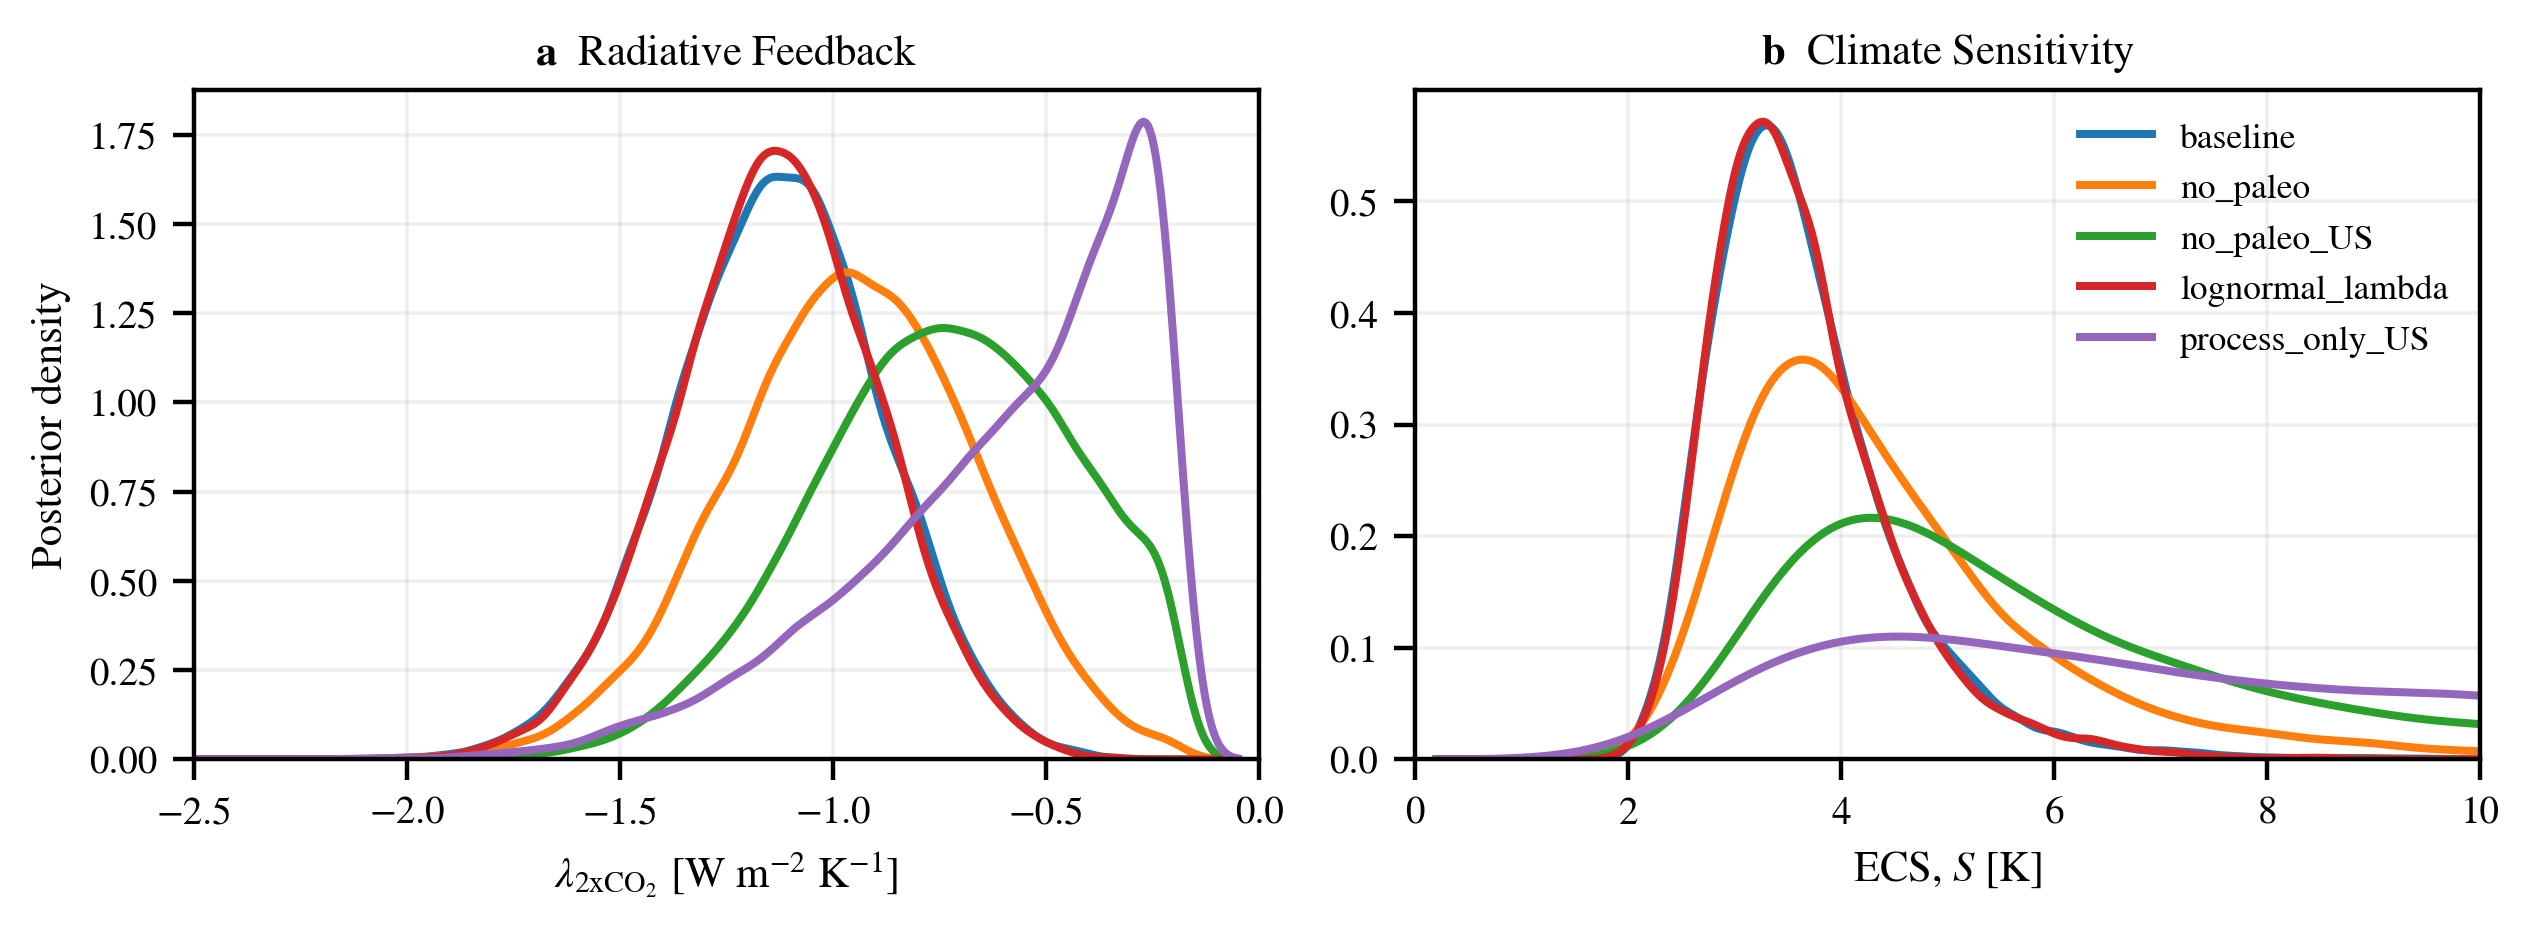

In [23]:
# Plot lambda and ECS posterior densities for every completed scenario.
posterior_lambda_grid = np.linspace(-2.5, -0.05, 500)
posterior_S_grid = np.linspace(0.2, 10.0, 500)

if results:
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160*2)
    for name, entry in results.items():
        axs[0].plot(
            posterior_lambda_grid,
            gaussian_kde(entry["lamb"])(posterior_lambda_grid),
            lw=1.8, label=name,
        )
        axs[1].plot(
            posterior_S_grid,
            gaussian_kde(entry["S"])(posterior_S_grid),
            lw=1.8, label=name,
        )

    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Posterior density",
        xlim=posterior_lambda_grid[[0, -1]],
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"ECS, $S$ [K]",
        xlim=posterior_S_grid[[0, -1]],
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2)
        # ax.set_title(ax.get_title(), loc="left")
    axs[1].legend(frameon=False, fontsize="small")

    axs[0].set_xlim(-2.5,0)
    axs[1].set_xlim(0,10)
    plt.tight_layout()
    plt.show()

## Likelihoods: Visualizing each line of evidence

These diagnostics use the same selectable $N$-based or $T$-based convention and nuisance distributions as the Stan model. Note that the likelihoods are helpful for illustration, but the Stan model samples the posterior directly, rather than calculating independent likelihoods and multiplying them. 
Set `score_T=True` in `calculate_likelihoods` for SW20 method score $T$.

Each curve is a relative likelihood, normalized to its own maximum. The $S$ curves are calculated directly as $L(\mathrm{data}\mid S)$ while marginalizing the assessed $F_{2\times CO_2}$ uncertainty; they are not transformed PDFs and therefore do not receive a Jacobian. The joint-paleo calculation averages the product of the LGM and Pliocene likelihoods using shared $F_{2\times CO_2}$ draws and correlated paleo pattern-effect draws. The joint Instrumental–Trend calculation evaluates the two budget residuals together, using their shared $F_{2\times CO_2}$ draw and the assessed cross-period aerosol and residual-other forcing covariances. Neither joint curve is obtained by multiplying the two separately marginalized curves.

In [42]:
likelihood_defaults = {
    # Quick, smooth defaults. Increase mc_draws/grid_points for publication.
    "lambda_min": -4.0,
    "lambda_max": -0.005,
    "S_min": 0.05,
    "S_max": 10.0,
    "grid_points": 2*260,
    "mc_draws": 30_000,
    "seed": 20250813,
}

individual_evidence = ("Process", "Instrumental", "Trend", "LGM", "Pliocene")
instrumental_trend_evidence = ("Instrumental", "Trend", "Joint Historical")
paleo_evidence = ("LGM", "Pliocene", "Joint paleo")
quasi_independent_evidence = ("Process", "Joint Historical", "Joint paleo")

likelihood_styles = {
    "Process": dict(color="navy", ls="-"),
    "Instrumental": dict(color="forestgreen", ls=":"),
    "Trend": dict(color="forestgreen", ls="--"),
    "Joint Historical": dict(color="darkgreen", ls="-"),
    "LGM": dict(color="royalblue", ls="-"),
    "Pliocene": dict(color="darkorange", ls="-"),
    "Joint paleo": dict(color="firebrick", ls="-"),
}


def _relative_likelihood(values):
    values = np.asarray(values, dtype=float)
    peak = np.nanmax(values)
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError("Likelihood curve has no finite positive values")
    return values / peak


def _normal_density_from_variance(observed, predicted_mean, variance):
    variance = np.maximum(np.asarray(variance, dtype=float), 1e-14)
    return np.exp(-0.5 * (observed - predicted_mean)**2 / variance) / np.sqrt(
        2 * np.pi * variance
    )


def _bivariate_normal_density_from_covariance(
    residual_x, residual_y, variance_x, variance_y, covariance_xy,
):
    """Evaluate a zero-mean bivariate-normal density from residuals."""
    variance_x = np.asarray(variance_x, dtype=float)
    variance_y = np.asarray(variance_y, dtype=float)
    determinant = variance_x * variance_y - covariance_xy**2
    if np.any(determinant <= 0):
        raise ValueError("Instrumental/Trend covariance is not positive definite")
    quadratic = (
        variance_y * residual_x**2
        - 2 * covariance_xy * residual_x * residual_y
        + variance_x * residual_y**2
    ) / determinant
    return np.exp(-0.5 * quadratic) / (2 * np.pi * np.sqrt(determinant))


def _meinshausen_co2_sarf(co2_ppm, n2o_ppb=273.0):
    co2_ppm = np.asarray(co2_ppm, dtype=float)
    a1, b1, c1, d1 = -2.4785e-7, 7.5906e-4, -2.1492e-3, 5.2488
    co2_ref = 277.15
    co2_alpha_max = co2_ref - b1 / (2 * a1)
    alpha_prime = np.where(
        co2_ppm <= co2_ref,
        d1,
        np.where(
            co2_ppm < co2_alpha_max,
            d1 + a1 * (co2_ppm - co2_ref)**2 + b1 * (co2_ppm - co2_ref),
            d1 - b1**2 / (4 * a1),
        ),
    )
    return (alpha_prime + c1 * np.sqrt(n2o_ppb)) * np.log(co2_ppm / co2_ref)


def _plio_co2_f2x_ratio(co2_ppm, co2_pi):
    return (
        _meinshausen_co2_sarf(co2_ppm) - _meinshausen_co2_sarf(co2_pi)
    ) / (
        _meinshausen_co2_sarf(2 * co2_pi) - _meinshausen_co2_sarf(co2_pi)
    )

In [43]:
def calculate_likelihoods(
    label="baseline", *, input_updates=None, settings_updates=None,
    process_correlation=False, score_T=False,
):
    """Calculate marginal likelihoods on lambda and S grids.

    input_updates changes assessed parameters for one sensitivity version.
    settings_updates changes grids, sample count, or seed.
    process_correlation=True applies rho_lambda_F2x to the Process curve.
    score_T=True rearranges every energy budget and scores temperature.
    """
    data = dict(base_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(f"Unknown likelihood inputs: {sorted(unknown_inputs)}")
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    # Common draws are reused across every grid point and line of evidence.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    dlambda_instrumental = skewnorm.rvs(
        a=data["shape_dlambda_instrumental"], loc=data["loc_dlambda_instrumental"],
        scale=data["scale_dlambda_instrumental"], size=n, random_state=rng,
    )
    dlambda_trend = rng.normal(
        data["mu_dlambda_trend"], data["sig_dlambda_trend"], n
    )

    paleo_dlambda_cov = np.array([
        [
            data["sig_dlambda_LGM"]**2,
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
        ],
        [
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
            data["sig_dlambda_plio"]**2,
        ],
    ])
    paleo_dlambda = rng.multivariate_normal(
        [data["mu_dlambda_LGM"], data["mu_dlambda_plio"]],
        paleo_dlambda_cov, size=n,
    )
    dlambda_lgm, dlambda_plio = paleo_dlambda.T
    f_co2_lgm = rng.normal(data["mu_f_CO2_LGM"], data["sig_f_CO2_LGM"], n)
    co2_plio = rng.normal(data["mu_CO2_plio"], data["sig_CO2_plio"], n)
    f_ch4 = rng.normal(data["mu_fCH4"], data["sig_fCH4"], n)
    f_co2_plio = _plio_co2_f2x_ratio(co2_plio, data["CO2_PI"])

    rho_process = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho_process < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    # Check each assessed instrumental-Trend forcing covariance before
    # combining them in the joint budget-residual likelihood.
    forcing_covariance_components = (
        (
            "anthropogenic aerosol",
            data["sig_F_anthro_aerosol_instrumental"],
            data["sig_F_anthro_aerosol_trend"],
            data["cov_F_anthro_aerosol_instrumental_trend"],
        ),
        (
            "residual other",
            data["sig_F_other_instrumental"],
            data["sig_F_other_trend"],
            data["cov_F_other_instrumental_trend"],
        ),
    )
    for component, sig_instrumental, sig_trend, covariance in forcing_covariance_components:
        if abs(covariance) >= sig_instrumental * sig_trend:
            raise ValueError(
                f"Instrumental-Trend {component} covariance is not positive definite"
            )
    instrumental_trend_forcing_covariance = (
        data["cov_F_anthro_aerosol_instrumental_trend"]
        + data["cov_F_other_instrumental_trend"]
    )

    instrumental_forcing_mean = (
        data["mu_F_CO2_instrumental"] * F2x / data["erf_2x"]
        + data["mu_F_anthro_aerosol_instrumental"] + data["mu_F_other_instrumental"]
    )
    instrumental_forcing_variance = (
        data["sig_F_anthro_aerosol_instrumental"]**2
        + data["sig_F_other_instrumental"]**2
    )

    def evaluate_at_lambda(lam, scalar_lambda, S_value=None):
        # Process: the lambda marginal is unchanged by its F2x correlation.
        if scalar_lambda:
            process_like = norm.pdf(lam, data["mu_lambda"], data["sig_lambda"])
        else:
            # Exact marginal for lambda = -F2x/S, including optional covariance.
            process_residual_mean = data["mu_lambda"] + data["erf_2x"] / S_value
            process_residual_variance = (
                data["sig_lambda"]**2
                + (data["sig_F2xCO2"] / S_value)**2
                + 2 * rho_process * data["sig_lambda"]
                * data["sig_F2xCO2"] / S_value
            )
            process_like = _normal_density_from_variance(
                0.0, process_residual_mean, process_residual_variance
            )

        beta_instrumental = lam - dlambda_instrumental
        instrumental_response_factor = np.abs(beta_instrumental) if score_T else 1.0
        instrumental_mean = instrumental_forcing_mean + data["mu_T_instrumental"] * beta_instrumental
        instrumental_variance = (
            data["sig_N_instrumental"]**2 + instrumental_forcing_variance
            + beta_instrumental**2 * data["sig_T_instrumental"]**2
        )
        instrumental_like = np.mean(
            instrumental_response_factor * _normal_density_from_variance(
                data["mu_N_instrumental"], instrumental_mean, instrumental_variance
            )
        )

        beta_trend = lam - dlambda_trend
        trend_response_factor = np.abs(beta_trend) if score_T else 1.0
        trend_forcing_mean = (
            data["mu_F_CO2_trend"] * F2x / data["erf_2x"]
            + data["mu_F_anthro_aerosol_trend"]
            + data["mu_F_other_trend"]
        )
        trend_mean = trend_forcing_mean + data["mu_T_trend"] * beta_trend
        trend_variance = (
            data["sig_N_trend"]**2
            + data["sig_F_anthro_aerosol_trend"]**2
            + data["sig_F_other_trend"]**2
            + beta_trend**2 * data["sig_T_trend"]**2
            - 2 * beta_trend * data["cov_TN_trend"]
        )
        trend_like = np.mean(
            trend_response_factor * _normal_density_from_variance(
                data["mu_N_trend"], trend_mean, trend_variance
            )
        )

        # Integrate the two energy-budget residuals jointly. Shared CO2
        # forcing uncertainty is represented by the common F2x draw; the
        # covariance below is only for aerosol plus residual-other forcing.
        joint_instrumental_trend_density = (
            instrumental_response_factor * trend_response_factor
            * _bivariate_normal_density_from_covariance(
                data["mu_N_instrumental"] - instrumental_mean,
                data["mu_N_trend"] - trend_mean,
                instrumental_variance,
                trend_variance,
                instrumental_trend_forcing_covariance,
            )
        )
        joint_instrumental_trend_like = np.mean(joint_instrumental_trend_density)

        beta_lgm = lam - dlambda_lgm
        lgm_response_factor = np.abs(beta_lgm) if score_T else 1.0
        lgm_mean = (
            data["mu_F_other_LGM"] + f_co2_lgm * F2x
            + data["mu_T_LGM"] * beta_lgm
        )
        lgm_variance = (
            data["sig_N_LGM"]**2 + data["sig_F_other_LGM"]**2
            + beta_lgm**2 * data["sig_T_LGM"]**2
        )
        lgm_density = lgm_response_factor * _normal_density_from_variance(
            data["mu_N_LGM"], lgm_mean, lgm_variance
        )

        beta_plio = lam - dlambda_plio
        plio_response_factor = np.abs(beta_plio) if score_T else 1.0
        plio_mean = (
            f_co2_plio * F2x * (1 + f_ch4)
            + data["mu_F_plio_nonGHG"]
            + data["mu_T_plio"] * beta_plio
        )
        plio_variance = (
            data["sig_N_plio"]**2 + data["sig_F_plio_nonGHG"]**2
            + beta_plio**2 * data["sig_T_plio"]**2
        )
        plio_density = plio_response_factor * _normal_density_from_variance(
            data["mu_N_plio"], plio_mean, plio_variance
        )

        return {
            "Process": process_like,
            "Instrumental": instrumental_like,
            "Trend": trend_like,
            "Joint Historical": joint_instrumental_trend_like,
            "LGM": np.mean(lgm_density),
            "Pliocene": np.mean(plio_density),
            # This is not the product of separately marginalized curves.
            "Joint paleo": np.mean(lgm_density * plio_density),
        }

    raw = {
        name: {"lambda": [], "S": []}
        for name in (*individual_evidence, "Joint Historical", "Joint paleo")
    }
    for lam in lambda_grid:
        evaluated = evaluate_at_lambda(lam, scalar_lambda=True)
        for name, value in evaluated.items():
            raw[name]["lambda"].append(value)
    for S in S_grid:
        evaluated = evaluate_at_lambda(-F2x / S, scalar_lambda=False, S_value=S)
        for name, value in evaluated.items():
            raw[name]["S"].append(value)

    curves = {
        name: {
            axis: _relative_likelihood(values)
            for axis, values in axis_values.items()
        }
        for name, axis_values in raw.items()
    }
    return {
        "label": label, "data": data, "settings": settings,
        "process_correlation": process_correlation,
        "score_T": score_T,
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw,
    }

In [44]:
def _format_likelihood_axes(axs, lambda_grid, S_grid, legend=True):
    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=(-4,0),
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"$S$ [K]", xlim=(0,10),
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)
        # ax.set_title(ax.get_title(), loc="left")
    if legend:
        axs[0].legend(frameon=False, fontsize="small")


def _print_likelihood_peaks(curves):
    """Print the lambda and S coordinates of each plotted maximum."""
    print("Peak locations")
    for label, lambda_grid, lambda_curve, S_grid, S_curve in curves:
        lambda_peak = np.asarray(lambda_grid)[np.nanargmax(lambda_curve)]
        S_peak = np.asarray(S_grid)[np.nanargmax(S_curve)]
        print(
            f"{label}: lambda = {lambda_peak:.3f} W m^-2 K^-1; "
            f"S = {S_peak:.3f} K"
        )


def plot_likelihoods(
    result, evidence=individual_evidence, *, process_pdf=None,
    report_peaks=True, title=None, save=None,
):
    """Plot selected evidence curves from one likelihood calculation.

    If process_pdf is supplied, the Process curve is plotted as a proper
    posterior PDF and the other likelihoods are scaled to the maximum of
    that PDF. Scaling is done separately in lambda and S space.
    """
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)

    if process_pdf is not None:
        process_curves = {
            "lambda": np.asarray(process_pdf["lambda_pdf"]),
            "S": np.asarray(process_pdf["S_pdf"]),
        }
        for parameter, grid in (
            ("lambda", result["lambda_grid"]),
            ("S", result["S_grid"]),
        ):
            pdf_grid = np.asarray(process_pdf[f"{parameter}_grid"])
            if pdf_grid.shape != np.asarray(grid).shape or not np.allclose(
                pdf_grid, grid
            ):
                raise ValueError(
                    f"The Process PDF and likelihood {parameter} grids must match"
                )
        process_peaks = {
            parameter: np.nanmax(curve)
            for parameter, curve in process_curves.items()
        }

    plotted_curves = []
    for name in evidence:
        style = likelihood_styles.get(name, {})
        label = "Process PDF" if process_pdf is not None and name == "Process" else name
        if process_pdf is not None and name == "Process":
            lambda_curve = process_curves["lambda"]
            S_curve = process_curves["S"]
        elif process_pdf is not None:
            lambda_curve = (
                result["curves"][name]["lambda"] * process_peaks["lambda"]
            )
            S_curve = result["curves"][name]["S"] * process_peaks["S"]
        else:
            lambda_curve = result["curves"][name]["lambda"]
            S_curve = result["curves"][name]["S"]
        axs[0].plot(
            result["lambda_grid"], lambda_curve,
            lw=1.8, label=label, **style,
        )
        axs[1].plot(
            result["S_grid"], S_curve,
            lw=1.8, label=label, **style,
        )
        plotted_curves.append((
            label, result["lambda_grid"], lambda_curve,
            result["S_grid"], S_curve,
        ))
    _format_likelihood_axes(axs, result["lambda_grid"], result["S_grid"])
    if process_pdf is not None:
        axs[0].set_ylabel(
            r"Process PDF / scaled likelihood [$(\mathrm{W\,m^{-2}\,K^{-1}})^{-1}$]"
        )
        axs[1].set_ylabel(r"Process PDF / scaled likelihood [K$^{-1}$]")
        for ax, parameter in zip(axs, ("lambda", "S")):
            ax.set_ylim(0, 1.05 * process_peaks[parameter])
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    if report_peaks:
        _print_likelihood_peaks(plotted_curves)
    return fig, axs


def plot_likelihood_versions(
    versions, evidence, *, styles=None, report_peaks=True,
    title=None, save=None,
):
    """Overlay one line of evidence from several sensitivity versions."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    plotted_curves = []
    for label, result in versions.items():
        if styles is None:
            style = {}
            if label in {"This Assessment", "SW20"}:
                style["ls"] = ":" if label == "SW20" else "-"
                evidence_color = likelihood_styles.get(evidence, {}).get("color")
                if evidence_color is not None:
                    style["color"] = evidence_color
        else:
            style = styles.get(label, {})
        axs[0].plot(
            result["lambda_grid"], result["curves"][evidence]["lambda"],
            lw=1.8, label=label, **style,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][evidence]["S"],
            lw=1.8, label=label, **style,
        )
        plotted_curves.append((
            label, result["lambda_grid"],
            result["curves"][evidence]["lambda"],
            result["S_grid"], result["curves"][evidence]["S"],
        ))
    first = next(iter(versions.values()))
    _format_likelihood_axes(axs, first["lambda_grid"], first["S_grid"])
    if title is None:
        title = f"{evidence} likelihood sensitivity"
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    if report_peaks:
        _print_likelihood_peaks(plotted_curves)
    return fig, axs


def calculate_process_only_posterior(
    result, *, lambda_prior_bounds=(-20.0, -0.01),
    process_correlation=False, forcing_grid_points=2_000,
):
    """Process-only posterior PDF for S under a fixed uniform-lambda prior.

    The Process likelihood and F2x assessment are combined in (F2x, lambda)
    space, then transformed to S=-F2x/lambda with the required F2x/S**2
    Jacobian. The returned S curve is an area-normalized PDF, not a
    peak-normalized likelihood.
    """
    data = result["data"]
    lambda_lower, lambda_upper = map(float, lambda_prior_bounds)
    if not lambda_lower < lambda_upper < 0:
        raise ValueError(
            "lambda_prior_bounds must satisfy lower < upper < 0"
        )

    rho = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    mu_F, sig_F = data["erf_2x"], data["sig_F2xCO2"]
    mu_lamb, sig_lamb = data["mu_lambda"], data["sig_lambda"]
    F_grid = np.linspace(
        max(1e-8, mu_F - 8 * sig_F),
        mu_F + 8 * sig_F,
        int(forcing_grid_points),
    )
    F_density = norm.pdf(F_grid, mu_F, sig_F)

    # Conditional lambda distribution implied by the optional bivariate
    # Gaussian Process/F2x assessment. With rho=0 this reduces to the
    # independent Process likelihood used by the baseline.
    conditional_lamb_mean = (
        mu_lamb + rho * sig_lamb / sig_F * (F_grid - mu_F)
    )
    conditional_lamb_sd = sig_lamb * np.sqrt(1 - rho**2)
    prior_interval_mass = (
        norm.cdf(
            (lambda_upper - conditional_lamb_mean) / conditional_lamb_sd
        )
        - norm.cdf(
            (lambda_lower - conditional_lamb_mean) / conditional_lamb_sd
        )
    )
    joint_normalization = np.trapz(
        F_density * prior_interval_mass, F_grid
    )

    S_grid = result["S_grid"]
    lamb_at_S = -F_grid[None, :] / S_grid[:, None]
    lamb_density_given_F = norm.pdf(
        (lamb_at_S - conditional_lamb_mean[None, :])
        / conditional_lamb_sd
    ) / conditional_lamb_sd
    inside_prior = (
        (lamb_at_S >= lambda_lower) & (lamb_at_S <= lambda_upper)
    )
    transformed_joint = (
        F_density[None, :] * lamb_density_given_F * inside_prior
        * F_grid[None, :] / S_grid[:, None]**2
    )
    S_pdf = np.trapz(transformed_joint, F_grid, axis=1) / joint_normalization

    lambda_grid = result["lambda_grid"]
    lambda_likelihood = norm.pdf(lambda_grid, mu_lamb, sig_lamb)
    lambda_prior_mass = (
        norm.cdf((lambda_upper - mu_lamb) / sig_lamb)
        - norm.cdf((lambda_lower - mu_lamb) / sig_lamb)
    )
    lambda_pdf = np.where(
        (lambda_grid >= lambda_lower) & (lambda_grid <= lambda_upper),
        lambda_likelihood / lambda_prior_mass,
        0.0,
    )
    return {
        "lambda_grid": lambda_grid,
        "lambda_likelihood": _relative_likelihood(lambda_likelihood),
        "lambda_pdf": lambda_pdf,
        "S_grid": S_grid,
        "S_pdf": S_pdf,
        "lambda_prior_bounds": (lambda_lower, lambda_upper),
        "process_correlation": process_correlation,
    }


def plot_process_likelihood_and_posterior(
    process_result, *, report_peaks=True,
    title="Process evidence", save=None,
):
    """Plot L(Process | lambda) and the process-only posterior PDF of S."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    style = likelihood_styles["Process"]
    axs[0].plot(
        process_result["lambda_grid"],
        process_result["lambda_likelihood"],
        lw=1.8, **style,
    )
    axs[1].plot(
        process_result["S_grid"], process_result["S_pdf"],
        lw=1.8, **style,
    )

    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=(-4, 0), ylim=(0, 1.05),
        title=r"$\mathbf{a}$  Process likelihood",
    )
    axs[1].set(
        xlabel=r"$S$ [K]", ylabel=r"Posterior density [K$^{-1}$]",
        xlim=(0, 10), ylim=(0, None),
        title=r"$\mathbf{b}$  Process-only posterior",
    )
    for ax in axs:
        ax.grid(alpha=0.2)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    if report_peaks:
        _print_likelihood_peaks([(
            "Process likelihood / posterior PDF",
            process_result["lambda_grid"],
            process_result["lambda_likelihood"],
            process_result["S_grid"], process_result["S_pdf"],
        )])
    return fig, axs

### Baseline likelihood calculation

This calculation includes all five individual diagnostics whether or not that line is enabled in a particular Stan run. Its Process-correlation choice follows `baseline_switches`.

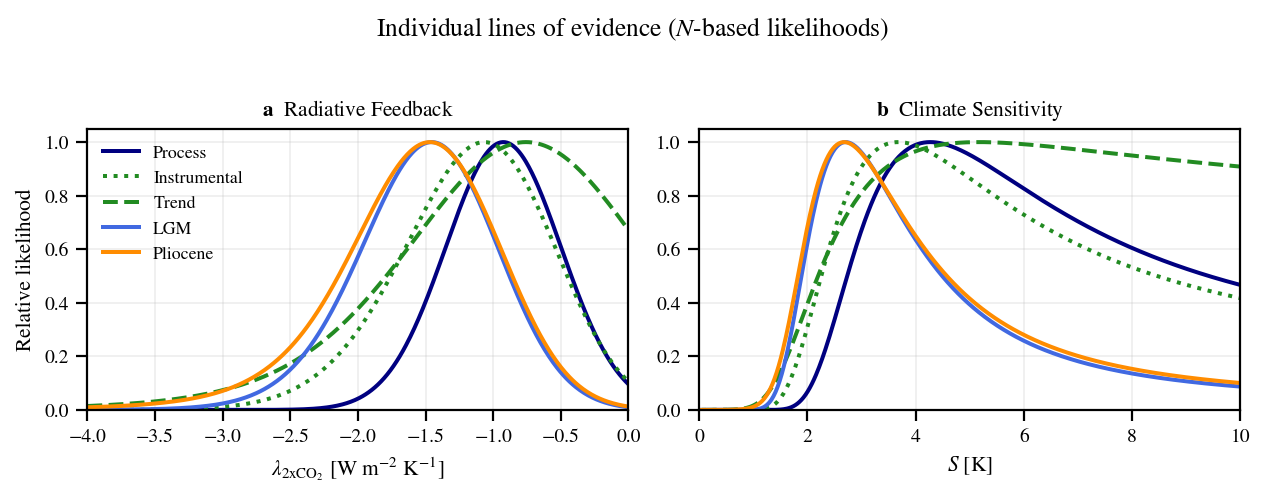

Peak locations
Process: lambda = -0.929 W m^-2 K^-1; S = 4.268 K
Instrumental: lambda = -1.067 W m^-2 K^-1; S = 3.673 K
Trend: lambda = -0.759 W m^-2 K^-1; S = 5.169 K
LGM: lambda = -1.452 W m^-2 K^-1; S = 2.715 K
Pliocene: lambda = -1.468 W m^-2 K^-1; S = 2.676 K


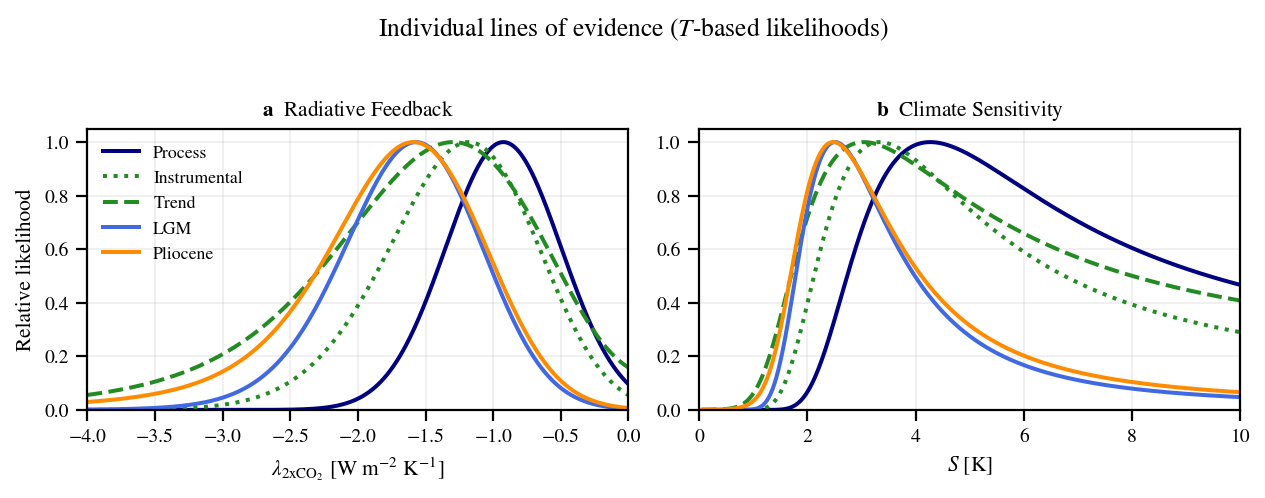

Peak locations
Process: lambda = -0.929 W m^-2 K^-1; S = 4.268 K
Instrumental: lambda = -1.183 W m^-2 K^-1; S = 3.328 K
Trend: lambda = -1.298 W m^-2 K^-1; S = 3.041 K
LGM: lambda = -1.568 W m^-2 K^-1; S = 2.504 K
Pliocene: lambda = -1.591 W m^-2 K^-1; S = 2.485 K


In [45]:
## Baseline (N-based)
likelihood_results = {}
likelihood_results["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=0,
)
likelihood_result_scoreN = likelihood_results["baseline"]

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=individual_evidence,
    title="Individual lines of evidence ($N$-based likelihoods)",
)
plt.show()

## T-based version
likelihood_results_scoreT = {}
likelihood_results_scoreT["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=1,
)
likelihood_result_scoreT = likelihood_results_scoreT["baseline"]
plot_likelihoods(
    likelihood_results_scoreT["baseline"],
    evidence=individual_evidence,
    title="Individual lines of evidence ($T$-based likelihoods)",
)
plt.show()

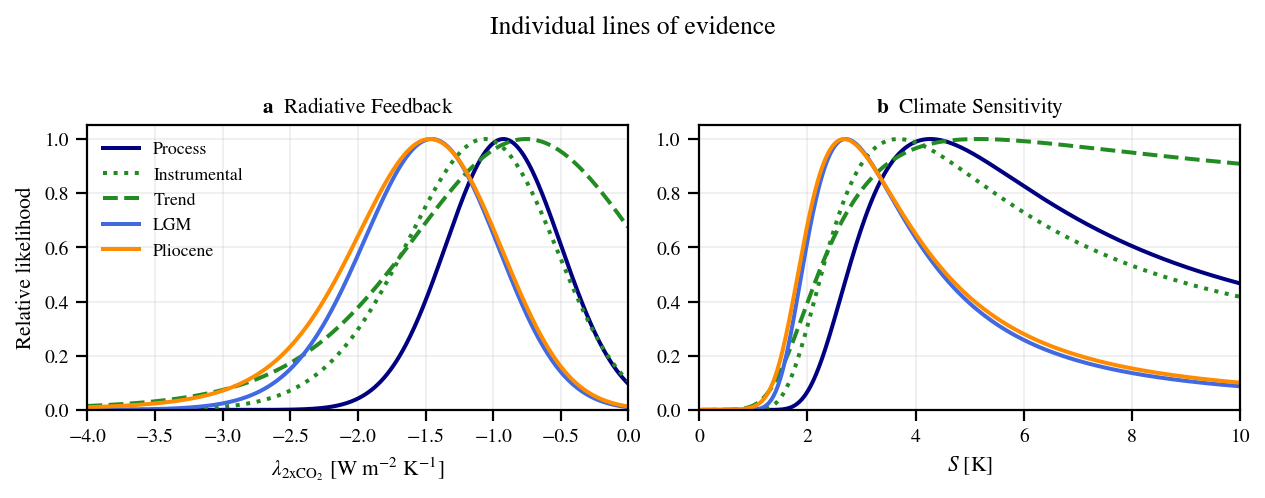

Peak locations
Process: lambda = -0.929 W m^-2 K^-1; S = 4.268 K
Instrumental: lambda = -1.067 W m^-2 K^-1; S = 3.673 K
Trend: lambda = -0.759 W m^-2 K^-1; S = 5.169 K
LGM: lambda = -1.452 W m^-2 K^-1; S = 2.715 K
Pliocene: lambda = -1.468 W m^-2 K^-1; S = 2.676 K


(<Figure size 1280x480 with 2 Axes>,
 array([<Axes: title={'center': '$\\mathbf{a}$  Radiative Feedback'}, xlabel='$\\lambda_\\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]', ylabel='Relative likelihood'>,
        <Axes: title={'center': '$\\mathbf{b}$  Climate Sensitivity'}, xlabel='$S$ [K]'>],
       dtype=object))

In [46]:
likelihood_results = {}
likelihood_results["baseline"] = calculate_likelihoods(
    "baseline",
    process_correlation=bool(baseline_switches["use_lambda_F2x_correlation"]),
    score_T=bool(baseline_switches["use_score_T"]),
)

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=individual_evidence,
    title="Individual lines of evidence",
)

### Process likelihood and process-only posterior

The left panel retains the Process likelihood in $\lambda$ space. The right panel instead shows the normalized posterior PDF of $S=-F_{2\times CO_2}/\lambda$ using only the Process evidence and the assessed $F_{2\times CO_2}$ distribution, with a fixed uniform prior over $-20 < \lambda < -0.01$ W m$^{-2}$ K$^{-1}$. The transformation includes the required $F_{2\times CO_2}/S^2$ Jacobian.

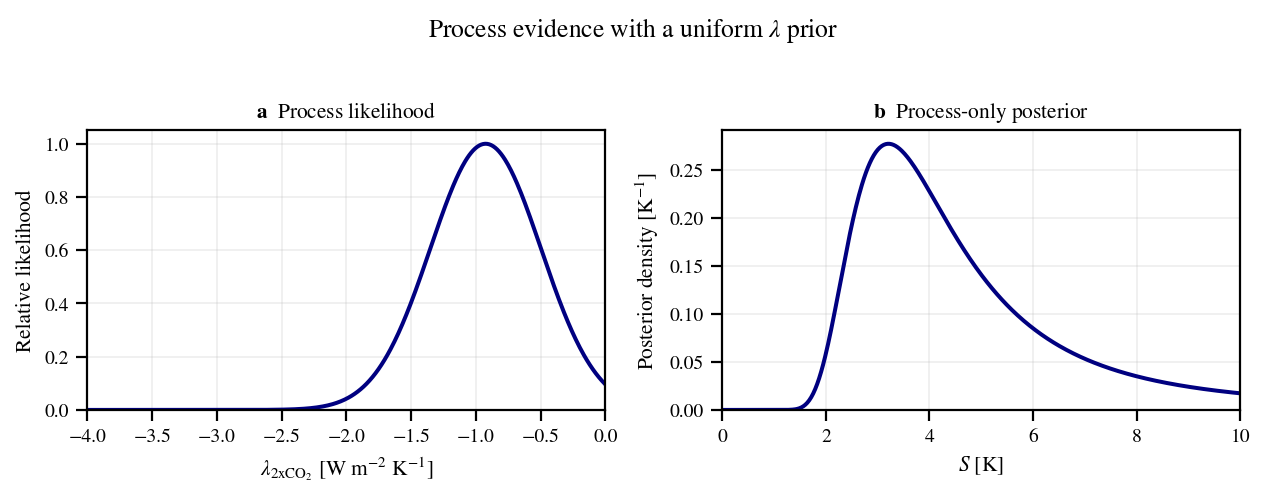

Peak locations
Process likelihood / posterior PDF: lambda = -0.929 W m^-2 K^-1; S = 3.213 K


(<Figure size 1280x480 with 2 Axes>,
 array([<Axes: title={'center': '$\\mathbf{a}$  Process likelihood'}, xlabel='$\\lambda_\\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]', ylabel='Relative likelihood'>,
        <Axes: title={'center': '$\\mathbf{b}$  Process-only posterior'}, xlabel='$S$ [K]', ylabel='Posterior density [K$^{-1}$]'>],
       dtype=object))

In [47]:
process_only_posterior = calculate_process_only_posterior(
    likelihood_results["baseline"],
    lambda_prior_bounds=(-20.0, -0.01),
    process_correlation=bool(
        baseline_switches["use_lambda_F2x_correlation"]
    ),
)

plot_process_likelihood_and_posterior(
    process_only_posterior,
    title=r"Process evidence with a uniform $\lambda$ prior",
)

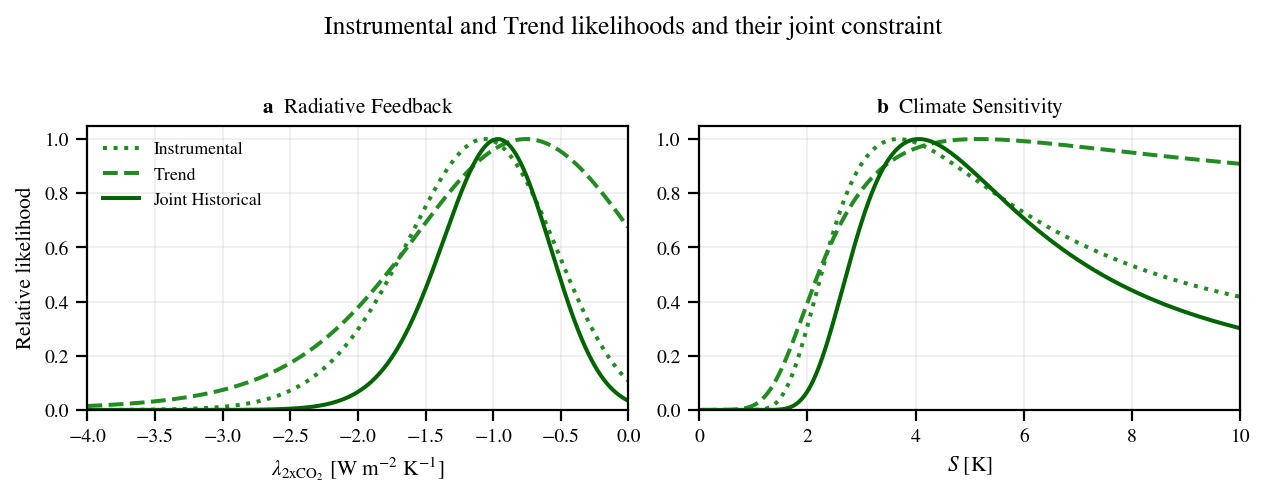

Peak locations
Instrumental: lambda = -1.067 W m^-2 K^-1; S = 3.673 K
Trend: lambda = -0.759 W m^-2 K^-1; S = 5.169 K
Joint Historical: lambda = -0.967 W m^-2 K^-1; S = 4.057 K


In [48]:
# Joint Historical uses shared F_2xCO2 draws and the assessed
# cross-period aerosol and residual-other forcing covariances. It is not
# the product of the separately marginalized Instrumental and Trend curves.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=instrumental_trend_evidence,
    title="Instrumental and Trend likelihoods and their joint constraint",
)
plt.show()

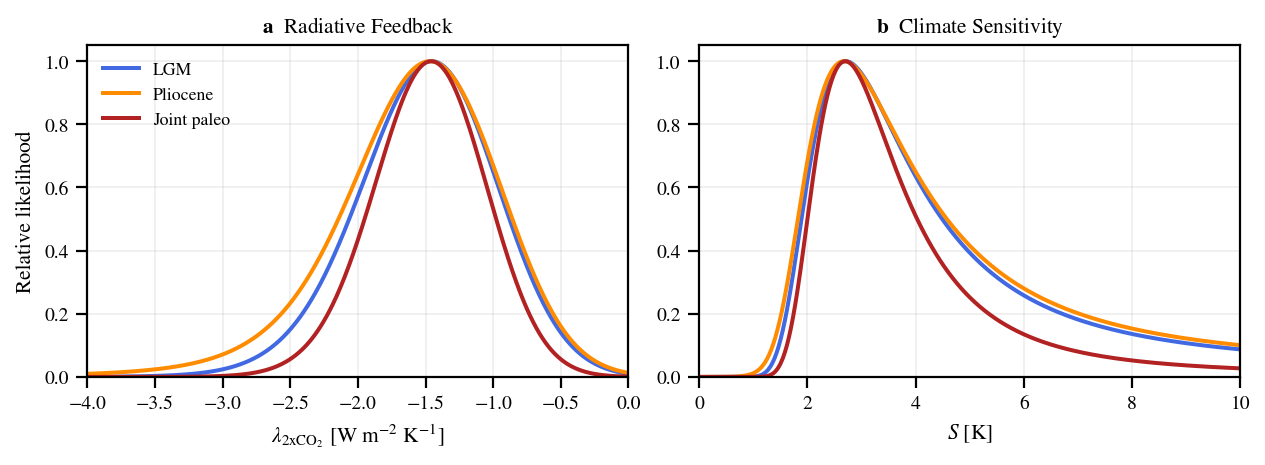

Peak locations
LGM: lambda = -1.452 W m^-2 K^-1; S = 2.715 K
Pliocene: lambda = -1.468 W m^-2 K^-1; S = 2.676 K
Joint paleo: lambda = -1.460 W m^-2 K^-1; S = 2.696 K


In [49]:
# Joint paleo uses shared F_2xCO2 draws and the assessed
# LGM-Pliocene pattern-effect correlation. It is not L_LGM * L_Pliocene.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=paleo_evidence,
    # title="Paleo likelihoods and their joint constraint",
)
plt.show()

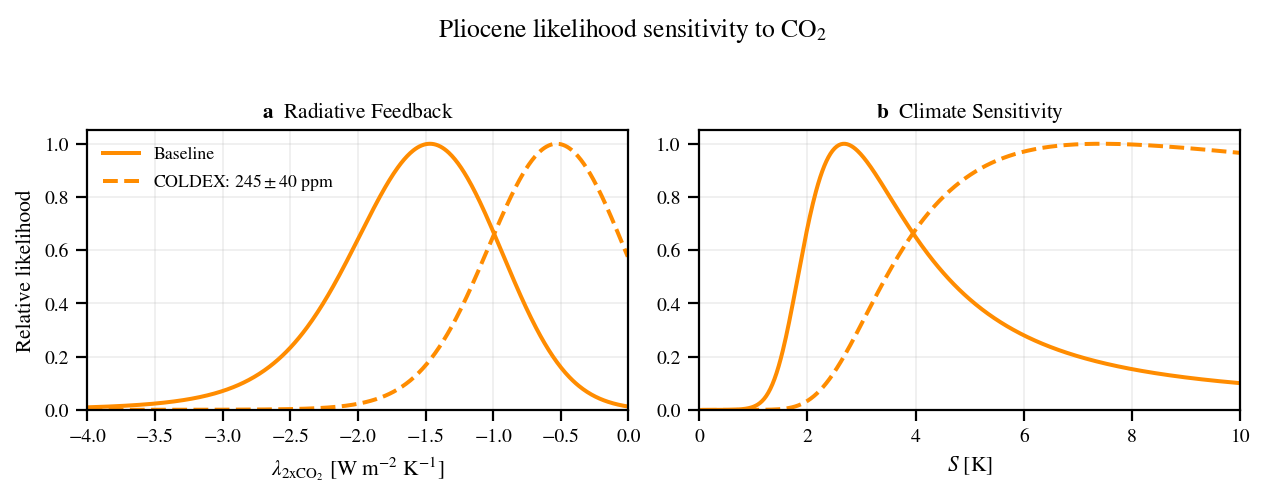

Peak locations
Baseline: lambda = -1.468 W m^-2 K^-1; S = 2.676 K
COLDEX: $245\pm40$ ppm: lambda = -0.528 W m^-2 K^-1; S = 7.431 K


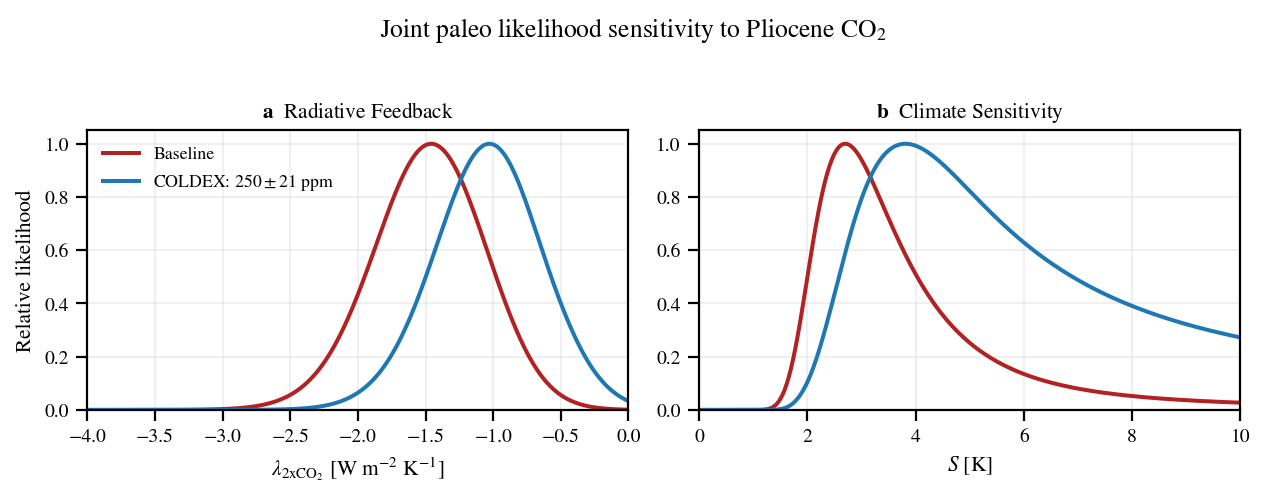

Peak locations
Baseline: lambda = -1.460 W m^-2 K^-1; S = 2.696 K
COLDEX: $250\pm21$ ppm: lambda = -1.029 W m^-2 K^-1; S = 3.808 K


In [53]:
## Calculate the likelihood with the COLDEX CO2 estimate.
likelihood_results["coldex_plio_co2"] = calculate_likelihoods(
    "COLDEX Pliocene CO2",
    input_updates={
        "mu_CO2_plio": 250.0,
        "sig_CO2_plio": 21.,
    },
    process_correlation=bool(
        baseline_switches["use_lambda_F2x_correlation"]
    ),
    score_T=bool(baseline_switches["use_score_T"]),
)

## Compare the Pliocene likelihoods.
plot_likelihood_versions(
    {
        "Baseline": likelihood_results["baseline"],
        r"COLDEX: $245\pm40$ ppm": likelihood_results["coldex_plio_co2"],
    },
    evidence="Pliocene",
    styles={
        "Baseline": dict(color="darkorange", ls="-"),
        r"COLDEX: $245\pm40$ ppm": dict(color="darkorange", ls="--"),
    },
    title="Pliocene likelihood sensitivity to CO$_2$",
)
plt.show()

plot_likelihood_versions(
    {
        "Baseline": likelihood_results["baseline"],
        r"COLDEX: $250\pm21$ ppm": likelihood_results["coldex_plio_co2"],
    },
    evidence="Joint paleo",
    styles={
        "Baseline": dict(color="firebrick", ls="-"),
        r"COLDEX: $245\pm40$ ppm": dict(color="firebrick", ls="--"),
    },
    title="Joint paleo likelihood sensitivity to Pliocene CO$_2$",
)
plt.show()

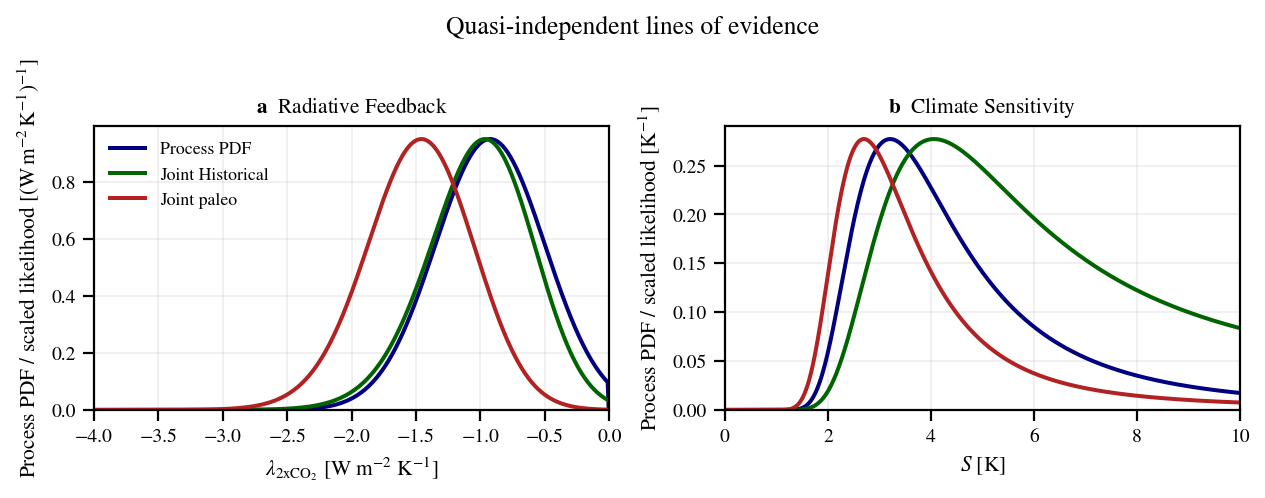

Peak locations
Process PDF: lambda = -0.929 W m^-2 K^-1; S = 3.213 K
Joint Historical: lambda = -0.967 W m^-2 K^-1; S = 4.057 K
Joint paleo: lambda = -1.460 W m^-2 K^-1; S = 2.696 K


In [51]:
## quasi-independent lines of evidence
## Set this to False to retain peak-normalized relative likelihoods.
## When True, the Process curve is its posterior PDF under the uniform
## lambda prior. The two joint likelihoods are rescaled to the Process
## PDF maximum in each panel; they are not normalized PDFs.
scale_joint_likelihoods_to_process_pdf = True

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=quasi_independent_evidence,
    process_pdf=(
        process_only_posterior
        if scale_joint_likelihoods_to_process_pdf else None
    ),
    title="Quasi-independent lines of evidence",
)
plt.show()

### SW20 LGM likelihood comparison

The compact parameter block below reproduces the SW20 LGM constraint using the distributions in their Table 7 and energy-budget Equation 22. Here $F'_{\mathrm{LGM}}$ contains all LGM forcing except CO$_2$. Score N evaluates the equilibrium budget residual at $N=0$; because $N$ is linear in $F'_{\mathrm{LGM}}$ with unit coefficient, this is equivalent to the forcing-scored likelihood in the original SW20 calculation. Score T instead solves the quadratic energy-budget equation and scores the reconstructed temperature on the cold-climate branch.

In [36]:
## SW20 Table 7 inputs. All uncertainties are 1 sigma.
sw20_lgm_inputs = {
    "erf_2x": 4.0,
    "sig_F2xCO2": 0.3,
    "mu_zeta": 0.06,
    "sig_zeta": 0.20,
    "mu_T_LGM": -5.0,
    "sig_T_LGM": 1.0,
    "mu_F_other_LGM": -6.15,
    "sig_F_other_LGM": 2.0,
    "f_CO2_LGM": -0.57,
    "mu_alpha": 0.10,
    "sig_alpha": 0.10,
}


def calculate_sw20_lgm_likelihood(
    label="SW20", *, score_T=False, input_updates=None,
    settings_updates=None,
):
    """Calculate the SW20 LGM likelihood in lambda and S space."""
    data = dict(sw20_lgm_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(f"Unknown SW20 LGM inputs: {sorted(unknown_inputs)}")
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ## Reuse common nuisance draws across the grids and both methods.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    zeta = rng.normal(data["mu_zeta"], data["sig_zeta"], n)
    alpha = rng.normal(data["mu_alpha"], data["sig_alpha"], n)
    T_lgm = rng.normal(data["mu_T_LGM"], data["sig_T_LGM"], n)
    F_other_lgm = rng.normal(
        data["mu_F_other_LGM"], data["sig_F_other_LGM"], n
    )

    def evaluate_at_lambda(lamb):
        with np.errstate(divide="ignore", invalid="ignore"):
            feedback_lgm = lamb / (1 + zeta)

            if not score_T:
                ## N = F' + f_CO2*F2x
                ##     + T*(lambda/(1+zeta) + alpha*T/2).
                budget_mean = (
                    data["mu_F_other_LGM"]
                    + data["f_CO2_LGM"] * F2x
                    + T_lgm * (feedback_lgm + 0.5 * alpha * T_lgm)
                )
                density = norm.pdf(
                    0.0, loc=budget_mean, scale=data["sig_F_other_LGM"]
                )
                return np.mean(np.where(np.isfinite(density), density, 0.0))

            ## Solve alpha*T^2/2 + feedback_lgm*T
            ##       + F' + f_CO2*F2x = 0.
            constant = data["f_CO2_LGM"] * F2x + F_other_lgm
            discriminant = feedback_lgm**2 - 2 * alpha * constant
            valid = (
                np.isfinite(discriminant) & (discriminant >= 0)
                & np.isfinite(feedback_lgm)
            )
            sqrt_discriminant = np.sqrt(np.maximum(discriminant, 0.0))

            ## This root is continuous with the linear solution as alpha -> 0.
            root_sign = np.where(feedback_lgm >= 0, 1.0, -1.0)
            denominator = feedback_lgm + root_sign * sqrt_discriminant
            valid &= np.abs(denominator) > 1e-12
            T_pred = np.full(n, np.nan)
            T_pred[valid] = -2 * constant[valid] / denominator[valid]
            valid &= np.isfinite(T_pred) & (T_pred < 0)

            density = np.zeros(n)
            density[valid] = norm.pdf(
                data["mu_T_LGM"], loc=T_pred[valid],
                scale=data["sig_T_LGM"],
            )
            return np.mean(density)

    raw_curves = {
        "LGM": {
            "lambda": np.asarray([
                evaluate_at_lambda(lamb) for lamb in lambda_grid
            ]),
            "S": np.asarray([
                evaluate_at_lambda(-F2x / S) for S in S_grid
            ]),
        }
    }
    curves = {
        "LGM": {
            axis: _relative_likelihood(values)
            for axis, values in raw_curves["LGM"].items()
        }
    }
    return {
        "label": label, "data": data, "settings": settings,
        "score_T": bool(score_T),
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw_curves,
    }


sw20_lgm_likelihood_results = {
    "N": calculate_sw20_lgm_likelihood("SW20, Score N", score_T=False),
    "T": calculate_sw20_lgm_likelihood("SW20, Score T", score_T=True),
}


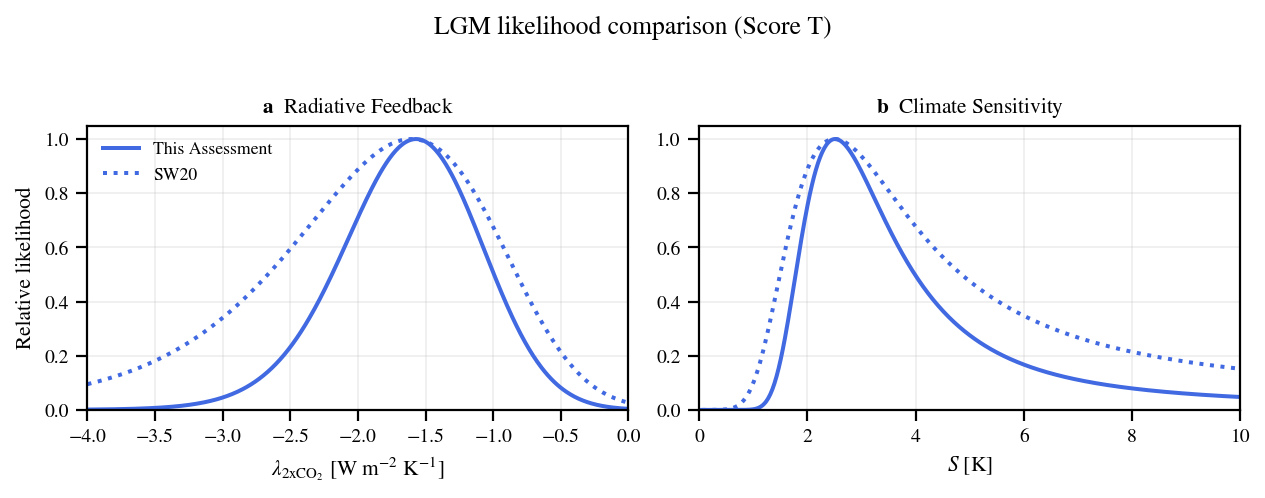

Peak locations
This Assessment: lambda = -1.568 W m^-2 K^-1; S = 2.504 K
SW20: lambda = -1.609 W m^-2 K^-1; S = 2.509 K


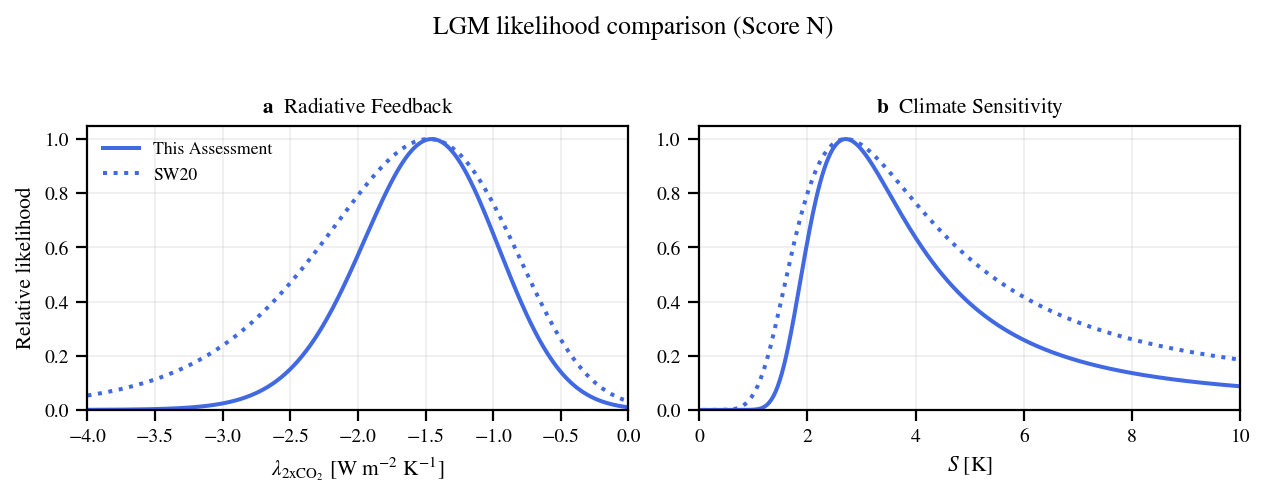

Peak locations
This Assessment: lambda = -1.452 W m^-2 K^-1; S = 2.715 K
SW20: lambda = -1.470 W m^-2 K^-1; S = 2.701 K


In [52]:
## Choose "N" or "T" here to compare the two response-variable methods.
lgm_score_method = "T"
lgm_score_method = lgm_score_method.upper()
if lgm_score_method not in {"N", "T"}:
    raise ValueError('lgm_score_method must be "N" or "T"')

this_assessment_lgm_results = {
    "N": likelihood_result_scoreN,
    "T": likelihood_result_scoreT,
}
plot_likelihood_versions(
    {
        "This Assessment": this_assessment_lgm_results[lgm_score_method],
        "SW20": sw20_lgm_likelihood_results[lgm_score_method],
    },
    evidence="LGM",
    title=f"LGM likelihood comparison (Score {lgm_score_method})",
)
plt.show()

## Choose "N" or "T" here to compare the two response-variable methods.
lgm_score_method = "N"
lgm_score_method = lgm_score_method.upper()
if lgm_score_method not in {"N", "T"}:
    raise ValueError('lgm_score_method must be "N" or "T"')

this_assessment_lgm_results = {
    "N": likelihood_result_scoreN,
    "T": likelihood_result_scoreT,
}
plot_likelihood_versions(
    {
        "This Assessment": this_assessment_lgm_results[lgm_score_method],
        "SW20": sw20_lgm_likelihood_results[lgm_score_method],
    },
    evidence="LGM",
    title=f"LGM likelihood comparison (Score {lgm_score_method})",
)
plt.show()

### SW20 Pliocene likelihood comparison

This uses the distributions in SW20 Table 8 and their Pliocene energy-budget Equation 23. Score T is the original SW20 response-variable convention. Score N evaluates the equivalent equilibrium budget at $N=0$; with no separate Pliocene imbalance uncertainty in SW20, its conditional spread comes from the assessed uncertainty in $T_{\mathrm{plio}}$.

In [38]:
## SW20 Table 8 inputs. All uncertainties are 1 sigma.
sw20_pliocene_inputs = {
    "erf_2x": 4.0,
    "sig_F2xCO2": 0.3,
    "mu_zeta": 0.06,
    "sig_zeta": 0.20,
    "mu_T_plio": 3.0,
    "sig_T_plio": 1.0,
    "mu_CO2_plio": 375.0,
    "sig_CO2_plio": 25.0,
    "co2_pi": 284.0,
    "mu_fCH4": 0.40,
    "sig_fCH4": 0.10,
    "mu_fESS": 0.50,
    "sig_fESS": 0.25,
}


def calculate_sw20_pliocene_likelihood(
    label="SW20", *, score_T=False, input_updates=None,
    settings_updates=None,
):
    """Calculate the SW20 Pliocene likelihood in lambda and S space."""
    data = dict(sw20_pliocene_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(
            f"Unknown SW20 Pliocene inputs: {sorted(unknown_inputs)}"
        )
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ## Common draws preserve the shared F2x dependence in S space.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    zeta = rng.normal(data["mu_zeta"], data["sig_zeta"], n)
    CO2_plio = rng.normal(data["mu_CO2_plio"], data["sig_CO2_plio"], n)
    fCH4 = rng.normal(data["mu_fCH4"], data["sig_fCH4"], n)
    fESS = rng.normal(data["mu_fESS"], data["sig_fESS"], n)

    def evaluate_at_lambda(lamb):
        with np.errstate(divide="ignore", invalid="ignore"):
            feedback_plio = lamb / (1 + zeta)
            F_plio_co2 = (
                np.log(CO2_plio / data["co2_pi"]) / np.log(2) * F2x
            )
            F_plio = F_plio_co2 * (1 + fCH4) * (1 + fESS)
            budget_mean = (
                F_plio + feedback_plio * data["mu_T_plio"]
            )
            budget_variance = (
                feedback_plio**2 * data["sig_T_plio"]**2
            )
            density = _normal_density_from_variance(
                0.0, budget_mean, budget_variance
            )
            if score_T:
                ## Equivalent to scoring T_plio against -F_plio/feedback_plio.
                density = np.abs(feedback_plio) * density

            valid = (
                (CO2_plio > 0) & np.isfinite(feedback_plio)
                & np.isfinite(density)
            )
            return np.mean(np.where(valid, density, 0.0))

    raw_curves = {
        "Pliocene": {
            "lambda": np.asarray([
                evaluate_at_lambda(lamb) for lamb in lambda_grid
            ]),
            "S": np.asarray([
                evaluate_at_lambda(-F2x / S) for S in S_grid
            ]),
        }
    }
    curves = {
        "Pliocene": {
            axis: _relative_likelihood(values)
            for axis, values in raw_curves["Pliocene"].items()
        }
    }
    return {
        "label": label, "data": data, "settings": settings,
        "score_T": bool(score_T),
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw_curves,
    }


sw20_pliocene_likelihood_results = {
    "N": calculate_sw20_pliocene_likelihood(
        "SW20, Score N", score_T=False
    ),
    "T": calculate_sw20_pliocene_likelihood(
        "SW20, Score T", score_T=True
    ),
}


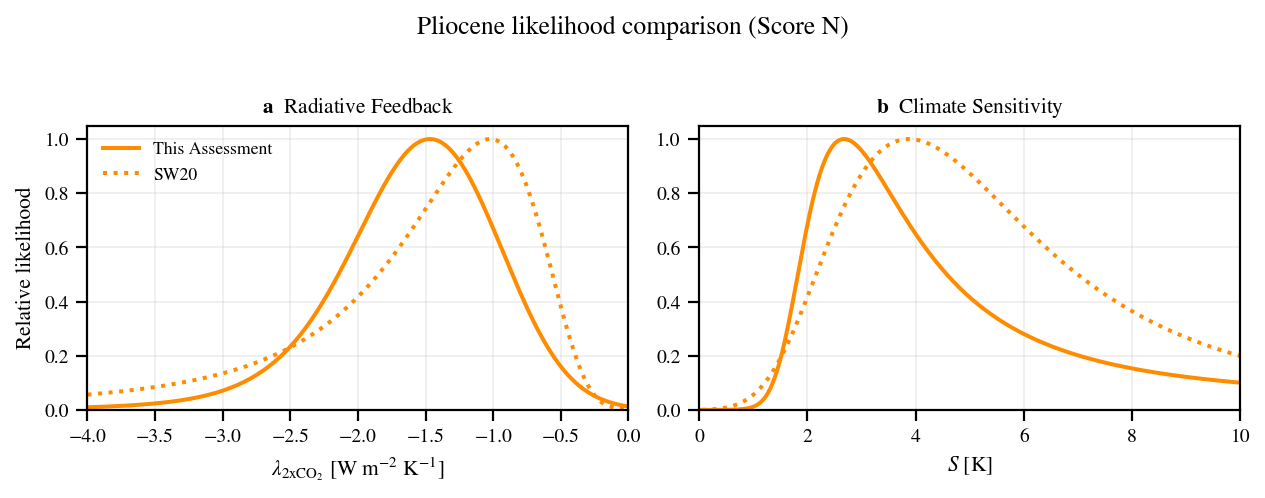

Peak locations
This Assessment: lambda = -1.470 W m^-2 K^-1; S = 2.662 K
SW20: lambda = -1.023 W m^-2 K^-1; S = 3.892 K


In [41]:
## Choose "N" or "T" here to compare the two response-variable methods.
pliocene_score_method = "N"
pliocene_score_method = pliocene_score_method.upper()
if pliocene_score_method not in {"N", "T"}:
    raise ValueError('pliocene_score_method must be "N" or "T"')

this_assessment_pliocene_results = {
    "N": likelihood_result_scoreN,
    "T": likelihood_result_scoreT,
}
plot_likelihood_versions(
    {
        "This Assessment": (
            this_assessment_pliocene_results[pliocene_score_method]
        ),
        "SW20": sw20_pliocene_likelihood_results[pliocene_score_method],
    },
    evidence="Pliocene",
    title=f"Pliocene likelihood comparison (Score {pliocene_score_method})",
)
plt.show()

### Sensitivity versions

Add named calculations to `likelihood_results`, changing only the parameters of interest. Because every version uses the same default seed, unchanged nuisance draws use common random numbers and differences between curves remain visually clean.

In [ ]:
## SCRATCH WORK
# how does the optional lambda/F2x Process correlation change
# the process likelihood in S space. Its lambda marginal is unchanged.
# likelihood_results["Process rho=-0.5"] = calculate_likelihoods(
#     "Process rho=-0.5", process_correlation=True
# )
# plot_likelihood_versions(
#     {
#         "independent": likelihood_results["baseline"],
#         r"$\rho=-0.5$": likelihood_results["Process rho=-0.5"],
#     },
#     evidence="Process",
# )

# Example: alternative LGM state-dependence multiplier uncertainty.
# likelihood_results["LGM multiplier sigma=0.08"] = calculate_likelihoods(
#     "LGM multiplier sigma=0.08",
#     input_updates={"sig_f_CO2_LGM": 0.08},
# )
# plot_likelihood_versions(
#     {
#         "baseline": likelihood_results["baseline"],
#         r"$\sigma(f_{CO2,LGM})=0.08$": likelihood_results["LGM multiplier sigma=0.08"],
#     },
#     evidence="LGM",
# )

# Example: compare the global score-N and score-T likelihood conventions.
# likelihood_results["score T"] = calculate_likelihoods(
#     "score T", score_T=True
# )
# plot_likelihood_versions(
#     {"score N": likelihood_results["baseline"],
#      "score T": likelihood_results["score T"]},
#     evidence="Instrumental",
# )

# For a higher-resolution final figure:
# final_settings = {"grid_points": 600, "mc_draws": 150_000}
# likelihood_results["final"] = calculate_likelihoods(
#     "final", settings_updates=final_settings
# )

# Prior scratch

In [ ]:
from scipy.stats import lognorm

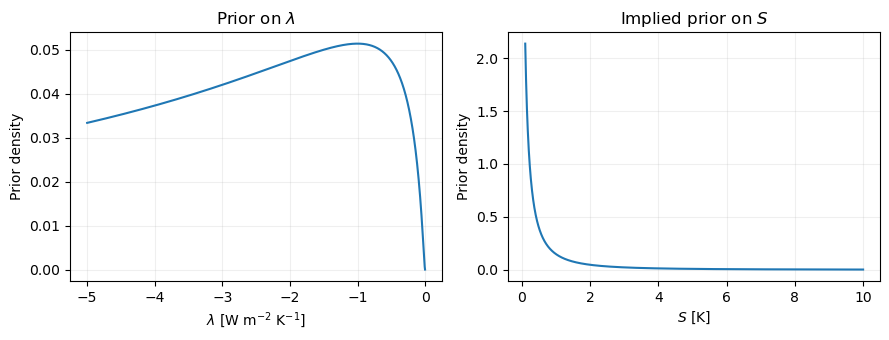

In [61]:
# lognormal_r_median = np.exp(1.0)       # 22.65
# lognormal_r_log_sigma = np.sqrt(.5)

lognormal_r_median = np.exp(3.0)       
lognormal_r_log_sigma = np.sqrt(3.)

# lognormal_r_median = np.exp(0)      
# lognormal_r_log_sigma = np.sqrt(2.500)
erf_2x = 3.93  # fixed here for the S transformation

lamb = np.linspace(-5, -0.001, 2000)
S = np.linspace(.1, 10, 2000)

# Prior on r = -lambda
pdf_lamb = lognorm.pdf(
    -lamb,
    s=lognormal_r_log_sigma,
    scale=lognormal_r_median,
)

# S = erf_2x / r
pdf_S = lognorm.pdf(
    S,
    s=lognormal_r_log_sigma,
    scale=erf_2x / lognormal_r_median,
)

fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))

axs[0].plot(lamb, pdf_lamb)
axs[0].set(xlabel=r"$\lambda$ [W m$^{-2}$ K$^{-1}$]",
           ylabel="Prior density",
           title=r"Prior on $\lambda$")

axs[1].plot(S, pdf_S)
axs[1].set(xlabel=r"$S$ [K]",
           ylabel="Prior density",
           title=r"Implied prior on $S$")

for ax in axs:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Process-feedback component assessment

The blue points are constructed directly from the process-feedback inputs at the top of the notebook, so changing those inputs and rerunning this cell updates the figure. The Planck feedback is plotted after adding 2 W m$^{-2}$ K$^{-1}$, as indicated on its axis label. Thick and thin intervals show central 66% and 90% Gaussian ranges.


In [ ]:
from matplotlib import ticker
from matplotlib.lines import Line2D

## Feedback order follows the current assessment table.
process_feedbacks = [
    "High cloud:\naltitude",
    "High cloud:\n" + r"$\mathrm{amount} + \tau$",
    "Low cloud:\nmarine",
    "Land\ncloud",
    "Other\ncloud",
    "Total\ncloud",
    "Planck\n" + r"$+2$ W m$^{-2}$ K$^{-1}$",
    "LR+WV",
    "Surface\nalbedo",
    "Other",
    "Total\n" + r"$\lambda_\mathrm{2xCO_2}$",
]

process_assessments = {
    "SW20": {
        "mean": [0.20, -0.20, 0.37, 0.08, np.nan, 0.45,
                 2 - 3.20, 1.15, 0.30, 0.00, -1.30],
        "sigma": [0.10, 0.20, 0.22, 0.08, np.nan, 0.34,
                  0.10, 0.18, 0.15, 0.15, 0.44],
        "color": "0.1",
    },
    "IPCC AR6": {
        "mean": [0.22, -0.15, 0.27, 0.08, np.nan, 0.42,
                 2 - 3.22, 1.30, 0.35, -0.01, -1.16],
        "sigma": [0.12, 0.20, 0.20, 0.08, np.nan, 0.33,
                  0.12, 0.12, 0.15, 0.16, 0.43],
        "color": "0.7",
    },
    "This assessment": {
        ## These values all refer back to the assessed inputs above.
        "mean": [
            highcloud_alt_mu,
            highcloud_amt_optdepth_mu,
            marine_lowcloud_mu,
            landcloud_mu,
            unassessed_cloud_mu,
            cloud_total_mu,
            2 + planck_mu,
            LRWV_mu,
            surfalbedo_mu,
            unassessed_mu,
            process_lamb_mu,
        ],
        "sigma": [
            highcloud_alt_sig,
            highcloud_amt_optdepth_sig,
            marine_lowcloud_sig,
            landcloud_sig,
            unassessed_cloud_sig,
            cloud_total_sig,
            planck_sig,
            LRWV_sig,
            surfalbedo_sig,
            unassessed_sig,
            process_lamb_sig,
        ],
        "color": "royalblue",
    },
}

z66 = 0.954
z90 = 1.645
x = np.arange(len(process_feedbacks))
offsets = [-0.22, 0.0, 0.22]

fig, ax = plt.subplots(figsize=(11, 4))

for offset, (name, values) in zip(offsets, process_assessments.items()):
    mean = np.asarray(values["mean"], dtype=float)
    sigma = np.asarray(values["sigma"], dtype=float)
    xpos = x + offset
    mask = np.isfinite(mean) & np.isfinite(sigma)

    ax.vlines(
        xpos[mask], mean[mask] - z90 * sigma[mask],
        mean[mask] + z90 * sigma[mask],
        color=values["color"], linewidth=1.5, zorder=1,
    )
    ax.vlines(
        xpos[mask], mean[mask] - z66 * sigma[mask],
        mean[mask] + z66 * sigma[mask],
        color=values["color"], linewidth=6, zorder=2,
    )
    ax.scatter(
        xpos[mask], mean[mask], color=values["color"], edgecolor="white",
        linewidth=0.7, s=55, zorder=3,
    )

ax.axhline(0, color="black", linewidth=1)
ax.axvline(4.5, color="0.5", linestyle=":", linewidth=1)
ax.axvline(9.5, color="0.5", linewidth=1)
ax.set_xlim(-0.5, len(process_feedbacks) - 0.5)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.grid(axis="y", linestyle=":", color="0.75", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(process_feedbacks)
ax.set_ylabel(r"Feedback $[\mathrm{W\,m^{-2}\,K^{-1}}]$")
ax.set_title("Process Assessment of Radiative Feedbacks", loc="left")

legend_items = [
    Line2D(
        [0], [0], marker="o", linestyle="none", color=values["color"],
        markersize=7, label=name,
    )
    for name, values in process_assessments.items()
] + [
    Line2D([0], [0], color="0.3", linewidth=6, label="66%"),
    Line2D([0], [0], color="0.3", linewidth=1.5, label="90%"),
]
ax.legend(handles=legend_items, ncol=5, frameon=False, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()
